In [38]:
import numpy as np
import mne
from scipy.signal import welch
import os.path as op
import matplotlib.pyplot as plt 
import pingouin as pg
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.lines as mlines
from scipy.interpolate import interp1d
import seaborn as sns
from fooof import FOOOFGroup
from fooof import FOOOF

path = '/users/mgarson.stu/.anaconda/VML'
meg_path = op.join(path, 'MEG')
mri_path = op.join(path, 'MRI')

adult_subs = ['011', '012', '013','014', '018','019', '021','022','025', '026', '030', '031']
child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']

fmin, fmax = 1, 90  # Frequency range for PSD (adjust as needed)
sfreq = 1000  # Adjust to your sampling frequency

# Function to extract PSD
def compute_psd(data, sfreq, fmin, fmax):
    freqs, psd = welch(data, sfreq, nperseg=sfreq, axis=-1, scaling='density')  # Welch's method
    freq_mask = (freqs >= fmin) & (freqs <= fmax)
    return freqs[freq_mask], psd[..., freq_mask]

#For baselines 
def compute_psd2(data, sfreq, fmin, fmax):
    freqs, psd = welch(data, fs=sfreq, nperseg=500, axis=-1, scaling='density')
    interp_freqs = np.arange(fmin, fmax + 1)  # 1 Hz steps
    interp_func = interp1d(freqs, psd, kind='linear', bounds_error=False, fill_value='extrapolate')
    psd_interp = interp_func(interp_freqs)
    return interp_freqs, psd_interp

In [2]:
#Read in Data for main figure 
g_el_cerebellum_normalized_psds = np.load(op.join('psd_data', 'el_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_ll_cerebellum_normalized_psds = np.load(op.join('psd_data', 'll_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_rl_cerebellum_normalized_psds = np.load(op.join('psd_data', 'rl_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_el_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'el_cerebellum_normalized_psds_c.npy'), allow_pickle=True)
g_ll_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'll_cerebellum_normalized_psds_c.npy'), allow_pickle=True)
g_rl_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'rl_cerebellum_normalized_psds_c.npy'), allow_pickle=True)

# Load Stds and significant frequencies
g_std_el_c = np.load(op.join('psd_data', 'std_el_c.npy'), allow_pickle=True)
g_std_ll_c = np.load(op.join('psd_data', 'std_ll_c.npy'), allow_pickle=True)
g_std_rl_c = np.load(op.join('psd_data', 'std_rl_c.npy'), allow_pickle=True)
g_std_el_c_c = np.load(op.join('psd_data', 'std_el_c_c.npy'), allow_pickle=True)
g_std_ll_c_c = np.load(op.join('psd_data', 'std_ll_c_c.npy'), allow_pickle=True)
g_std_rl_c_c = np.load(op.join('psd_data', 'std_rl_c_c.npy'), allow_pickle=True)

g_sig_freqs_cereb_age = np.load(op.join('psd_data', 'sig_freqs_cereb_age.npy'), allow_pickle=True)
g_sig_freqs_cereb_cond = np.load(op.join('psd_data', 'sig_freqs_cereb_cond.npy'), allow_pickle=True)
g_sig_freqs_cereb_int = np.load(op.join('psd_data', 'sig_freqs_cereb_int.npy'), allow_pickle=True)

g_el_motor_normalized_psds = np.load(op.join('psd_data', 'el_motor_normalized_psds.npy'), allow_pickle=True)
g_ll_motor_normalized_psds = np.load(op.join('psd_data', 'll_motor_normalized_psds.npy'), allow_pickle=True)
g_rl_motor_normalized_psds = np.load(op.join('psd_data', 'rl_motor_normalized_psds.npy'), allow_pickle=True)
g_el_motor_normalized_psds_c = np.load(op.join('psd_data', 'el_motor_normalized_psds_c.npy'), allow_pickle=True)
g_ll_motor_normalized_psds_c = np.load(op.join('psd_data', 'll_omtor_normalized_psds_c.npy'), allow_pickle=True)  # Fixed "ll_omtor" typo
g_rl_motor_normalized_psds_c = np.load(op.join('psd_data', 'rl_motor_normalized_psds_c.npy'), allow_pickle=True)

g_el_m_std = np.load(op.join('psd_data', 'el_m_std.npy'), allow_pickle=True)
g_ll_m_std = np.load(op.join('psd_data', 'll_m_std.npy'), allow_pickle=True)
g_rl_m_std = np.load(op.join('psd_data', 'rl_m_std.npy'), allow_pickle=True)
g_el_m_c_std = np.load(op.join('psd_data', 'el_m_std_c.npy'), allow_pickle=True)
g_ll_m_c_std = np.load(op.join('psd_data', 'll_m_std_c.npy'), allow_pickle=True)
g_rl_m_c_std = np.load(op.join('psd_data', 'rl_m_std_c.npy'), allow_pickle=True)

g_sig_freqs_m_age = np.load(op.join('psd_data', 'sig_freqs_m_age.npy'), allow_pickle=True)
g_sig_freqs_m_cond = np.load(op.join('psd_data', 'sig_freqs_m_cond.npy'), allow_pickle=True)
g_sig_freqs_m_int = np.load(op.join('psd_data', 'sig_freqs_m_int.npy'), allow_pickle=True)


Reading labels from parcellation...
   read 35 labels from c:\users\mgarson.stu\.anaconda\VML\MRI\fsaverage\label\lh.aparc.annot
   read 34 labels from c:\users\mgarson.stu\.anaconda\VML\MRI\fsaverage\label\rh.aparc.annot
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)
1701


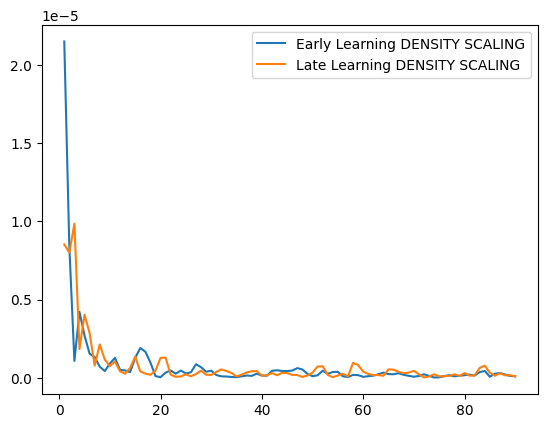

In [ ]:
'''LOGIC FOR THE REST OF THE REST OF THE SCRIPT: 
    1. READ IN STC FILES (DS LOCALIZED)
    2. EXTRACT TC OF A SPECIFIC ROI
    3. COMPUTE PSD WITH WELCH AND FREQ PARAMETERS: RETURNS (FREQUENCY_LIST, POWER_LIST)'''


adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)
labels = mne.read_labels_from_annot('fsaverage', parc='aparc', subjects_dir=mri_path)
precentral_lh = [label for label in labels if label.name == 'precentral-lh']

stc_t2 = mne.read_source_estimate(op.join(meg_path, f'vml_meg_012', f'morphed_DS_012_cond-run 3-stc.h5'))
stc_t1 = mne.read_source_estimate(op.join(meg_path, f'vml_meg_012', f'morphed_DS_012_cond-run 2 -stc.h5'))

t1 = mne.extract_label_time_course(stc_t1, src=adult_src, labels=precentral_lh, mode='mean')[0]
t2 = mne.extract_label_time_course(stc_t2, src=adult_src, labels=precentral_lh, mode='mean')[0]

#print(len(t1)) # == number of time points in the epoch. 

bp1 = compute_psd(t1, sfreq, fmin, fmax)
bp2 = compute_psd(t2, sfreq, fmin, fmax)

plt.plot(bp1[0], bp1[1], label='Early Learning DENSITY SCALING')
plt.plot(bp2[0], bp2[1], label='Late Learning DENSITY SCALING')
plt.legend()

C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\2173896156.py:29: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_011\011-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\2173896156.py:29: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_012\012-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\2173896156.py:29: 

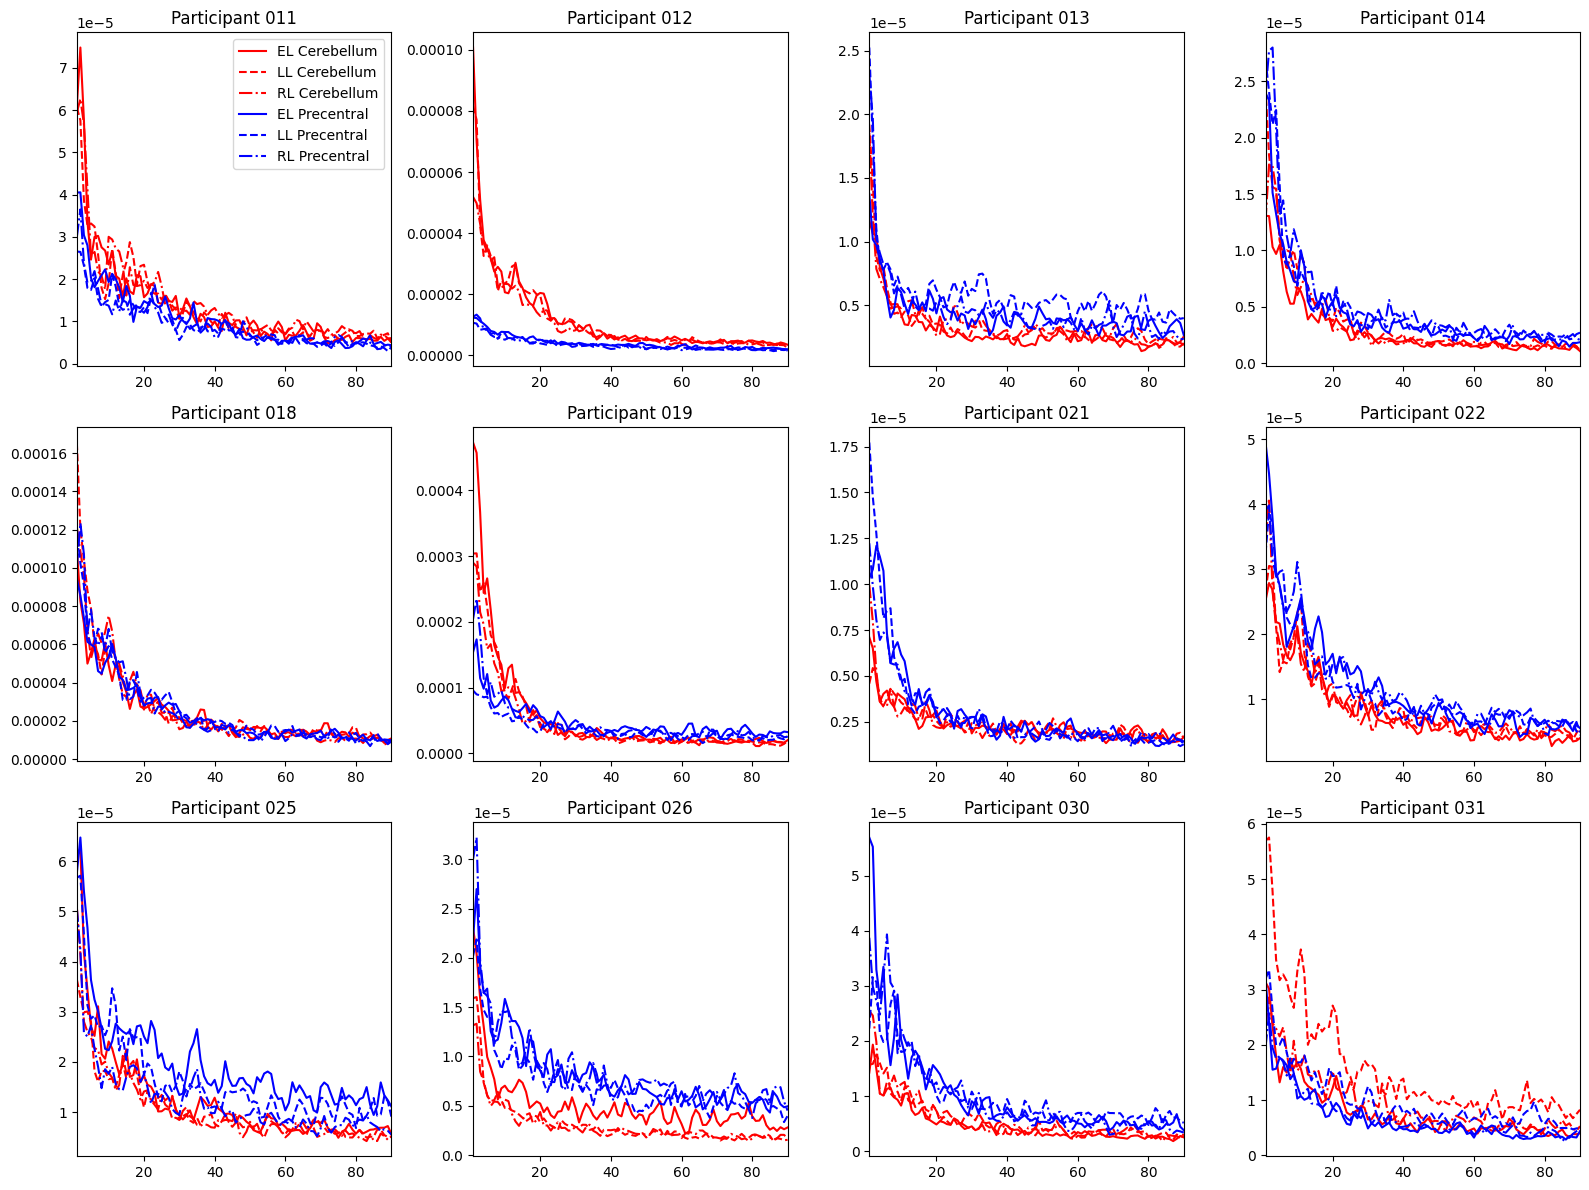

In [8]:
'''RATHER THAN COMPUTING THE PSD ON THE FINAL STC PLOT, WE GO EPOCH-> STC -> PSD 
    AND ONLY THEN AVERAGE ALL OF THE PSDS, DOING THIS FOR EACH SUBJECT. 
    Max's Conventions: 
    EL = EARLY LEARNING
    LL = LATE LEARNING 
    RL = RE LEARNING
    LH = LEFT HEMI
    RH = RIGHT HEMI 

    OTHER TRICKY TIP: To extract TC from the cerebellum, use: *** INDEXING IS CRUCIAL ***  
    cerebellum = mne.extract_label_time_course(stc, src=src, labels=vol_labels, mode='mean', verbose=False)[:4]
    cerebellum_rh = np.mean((cerebellum[0], cerebellum[1]), axis=0) 
    cerebellum_lh = np.mean((cerebellum[2], cerebellum[3]), axis=0) 
    '''

sfreq, fmin, fmax = 1000, 1, 90

# Initialize the figure
fig, axes = plt.subplots(3, 4, figsize=(16, 12))  # Grid for 12 participants
axes = axes.flatten()  # Flatten for easy indexing

#Store PSD results (MOTOR + CEREBELLUM stored sepperately):
el_cerebellum_psds, el_motor_psds = [], []
ll_cerebellum_psds, ll_motor_psds = [], [] 
rl_cerebellum_psds, rl_motor_psds = [], []

# Loop through the participants
for i, sub in enumerate(adult_subs): 
    fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
    src = fwd['src']
    labels = mne.read_labels_from_annot(f'vml_mri_{sub}', parc='aparc', subjects_dir=mri_path, verbose=False)

    #Different Surface Labels (WE DONT USE ALL BUT FOLLOW THE SAME CODE STEPS IF YOU WANT TO LOOK AT SAY PARIETAL...)
    precentral_lh = [label for label in labels if label.name == 'precentral-lh']
    precentral_rh = [label for label in labels if label.name == 'precentral-rh']
    superior_parietal_lh = [label for label in labels if label.name == 'superiorparietal-lh']
    superior_parietal_rh = [label for label in labels if label.name == 'superiorparietal-rh']
    lh_frontal = [label for label in labels if label.name == 'rostralmiddlefrontal-lh']
    rh_frontal = [label for label in labels if label.name == 'rostralmiddlefrontal-rh']
    lh_occipital = [label for label in labels if label.name == 'lateraloccipital-lh']
    rh_occipital = [label for label in labels if label.name == 'lateraloccipital-rh']
    lh_temporal = [label for label in labels if label.name == 'superiortemporal-lh']
    rh_temporal = [label for label in labels if label.name == 'superiortemporal-rh']

    vol_labels = mne.get_volume_labels_from_src(src, subject=f'vml_mri_{sub}', subjects_dir=mri_path) 
    filters = mne.beamformer.read_beamformer(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-run_filters-lcmv.h5'))
    epochs = mne.read_epochs(op.join(path, 'MEG', f'vml_meg_{sub}', f'vml_meg_{sub}_run_epochs-epo.fif'), verbose=False)

    el_epochs, ll_epochs, rl_epochs = epochs['run2'], epochs['run3'], epochs['run4']
    el_stcs = mne.beamformer.apply_lcmv_epochs(el_epochs, filters, return_generator=False, verbose=False)
    ll_stcs = mne.beamformer.apply_lcmv_epochs(ll_epochs, filters, return_generator=False, verbose=False)
    rl_stcs = mne.beamformer.apply_lcmv_epochs(rl_epochs, filters, return_generator=False, verbose=False)

    def compute_avg_psd(stcs):
        cerebellum_psd, precentral_psd, parietal_lh_psd, parietal_rh_psd, frontal_lh_psd, frontal_rh_psd, occipital_lh_psd, occipital_rh_psd, temporal_lh_psd, temporal_rh_psd = [], [], [], [], [], [], [], [], [], []
        for stc in stcs:
            stc.data = abs(stc.data) 
            cerebellum = mne.extract_label_time_course(stc, src=src, labels=vol_labels, mode='mean', verbose=False)[:4]
            cerebellum_rh = np.mean((cerebellum[0], cerebellum[1]), axis=0)
            precentral = mne.extract_label_time_course(stc, src=src, labels=precentral_lh, mode='mean', verbose=False)[0] 
            parietal_lh = mne.extract_label_time_course(stc, src=src, labels=superior_parietal_lh, mode='mean', verbose=False)[0]
            parietal_rh = mne.extract_label_time_course(stc, src=src, labels=superior_parietal_rh, mode='mean', verbose=False)[0]
            frontal_lh = mne.extract_label_time_course(stc, src=src, labels=lh_frontal, mode='mean', verbose=False)[0]
            frontal_rh = mne.extract_label_time_course(stc, src=src, labels=rh_frontal, mode='mean', verbose=False)[0]
            occipital_lh = mne.extract_label_time_course(stc, src=src, labels=lh_occipital, mode='mean', verbose=False)[0]
            occipital_rh = mne.extract_label_time_course(stc, src=src, labels=rh_occipital, mode='mean', verbose=False)[0]
            temporal_lh = mne.extract_label_time_course(stc, src=src, labels=lh_temporal, mode='mean', verbose=False)[0]
            temporal_rh = mne.extract_label_time_course(stc, src=src, labels=rh_temporal, mode='mean', verbose=False)[0]

            freqs = compute_psd(cerebellum_rh, sfreq, fmin, fmax)[0]
            cerebellum_psd.append(compute_psd(cerebellum_rh, sfreq, fmin, fmax)[1])
            precentral_psd.append(compute_psd(precentral, sfreq, fmin, fmax)[1])
            parietal_lh_psd.append(compute_psd(parietal_lh, sfreq, fmin, fmax)[1])
            parietal_rh_psd.append(compute_psd(parietal_rh, sfreq, fmin, fmax)[1])
            frontal_lh_psd.append(compute_psd(frontal_lh, sfreq, fmin, fmax)[1])
            frontal_rh_psd.append(compute_psd(frontal_rh, sfreq, fmin, fmax)[1])
            occipital_lh_psd.append(compute_psd(occipital_lh, sfreq, fmin, fmax)[1])
            occipital_rh_psd.append(compute_psd(occipital_rh, sfreq, fmin, fmax)[1])
            temporal_lh_psd.append(compute_psd(temporal_lh, sfreq, fmin, fmax)[1])
            temporal_rh_psd.append(compute_psd(temporal_rh, sfreq, fmin, fmax)[1])

        return freqs, np.mean(np.vstack(cerebellum_psd), axis=0), np.mean(np.vstack(precentral_psd), axis=0), np.mean(np.vstack(parietal_lh_psd), axis=0), np.mean(np.vstack(parietal_rh_psd), axis=0), \
        np.mean(np.vstack(frontal_lh_psd), axis=0), np.mean(np.vstack(frontal_rh_psd), axis=0), np.mean(np.vstack(occipital_lh_psd), axis=0), np.mean(np.vstack(occipital_rh_psd), axis=0), \
        np.mean(np.vstack(temporal_lh_psd), axis=0), np.mean(np.vstack(temporal_rh_psd), axis=0)

    freqs, avg_power_el_cerebellum, avg_power_el_precentral, avg_power_el_parietal_lh, avg_power_el_parietal_rh, avg_power_el_frontal_lh, avg_power_el_frontal_rh, avg_power_el_occipital_lh, avg_power_el_occipital_rh, avg_power_el_frontal_lh, avg_power_el_frontal_rh=compute_avg_psd(el_stcs)
    _, avg_power_ll_cerebellum, avg_power_ll_precentral, avg_power_ll_parietal_lh, avg_power_ll_parietal_rh, avg_power_ll_frontal_lh, avg_power_ll_frontal_rh, avg_power_ll_occipital_lh, avg_power_ll_occipital_rh, avg_power_ll_frontal_lh, avg_power_ll_frontal_rh = compute_avg_psd(ll_stcs)
    _, avg_power_rl_cerebellum, avg_power_rl_precentral, avg_power_rl_parietal_lh, avg_power_rl_parietal_rh, avg_power_rl_frontal_lh, avg_power_rl_frontal_rh, avg_power_rl_occipital_lh, avg_power_rl_occipital_rh, avg_power_rl_frontal_lh, avg_power_rl_frontal_rh = compute_avg_psd(rl_stcs)
    
    #Store the results: 
    el_cerebellum_psds.append(avg_power_el_cerebellum)
    ll_cerebellum_psds.append(avg_power_ll_cerebellum)
    rl_cerebellum_psds.append(avg_power_rl_cerebellum)
    el_motor_psds.append(avg_power_el_precentral)
    ll_motor_psds.append(avg_power_ll_precentral)
    rl_motor_psds.append(avg_power_rl_precentral)
    
    # Plot for this participant
    ax = axes[i]
    ax.plot(freqs, avg_power_el_cerebellum, label='EL Cerebellum', color='red', linestyle='solid')
    ax.plot(freqs, avg_power_ll_cerebellum, label='LL Cerebellum', color='red', linestyle='dashed')
    ax.plot(freqs, avg_power_rl_cerebellum, label='RL Cerebellum', color='red', linestyle='dashdot')
    ax.plot(freqs, avg_power_el_precentral, label='EL Precentral', color='blue', linestyle='solid')
    ax.plot(freqs, avg_power_ll_precentral, label='LL Precentral', color='blue', linestyle='dashed')
    ax.plot(freqs, avg_power_rl_precentral, label='RL Precentral', color='blue', linestyle='dashdot')
    # ax.plot(freqs, avg_power_el_parietal_lh, label='LH Parietal EL', color='red', linestyle='solid')
    # ax.plot(freqs, avg_power_el_parietal_rh, label='RH Parietal EL', color='blue', linestyle='solid')
    # ax.plot(freqs, avg_power_ll_parietal_lh, label='LH Parietal LL', color='red', linestyle='dashed')
    # ax.plot(freqs, avg_power_ll_parietal_rh, label='RH Parietal LL', color='blue', linestyle='dashed')

    ax.set_xlim(fmin, fmax)
    ax.set_title(f'Participant {sub}')
    if i == 0: 
        ax.legend()

    del el_stcs, ll_stcs, rl_stcs

plt.tight_layout()
plt.show()


C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\3290959917.py:16: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_003\003-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\3290959917.py:16: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_002\002-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\3290959917.py:16: 

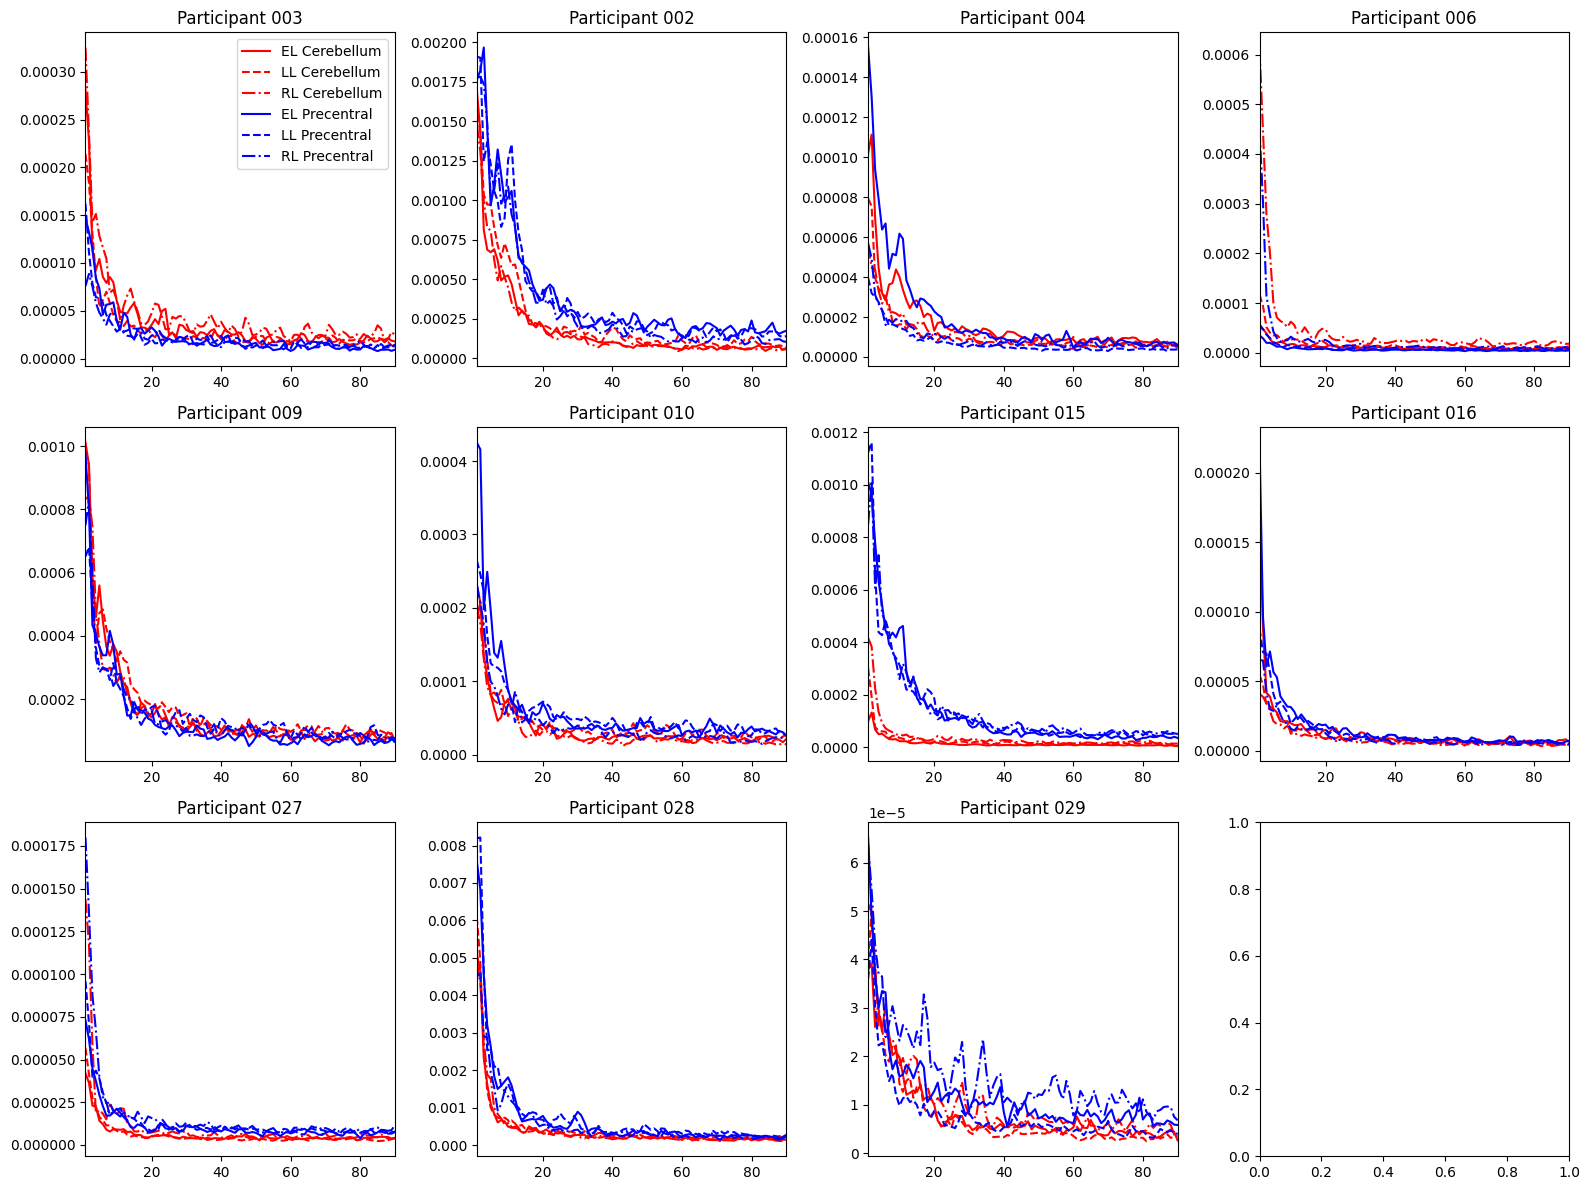

In [19]:
'''SAME CODE BUT FOR THE CHILDREN NOW'''

# Initialize the figure
fig, axes = plt.subplots(3, 4, figsize=(16, 12))  # Grid for 12 participants
axes = axes.flatten()  # Flatten for easy indexing

child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']
child_sub_ages = ['6.95', '10.85', '10.49', '7.04', '7.89', '9.71', '7.76', '11.36', '8.65', '6.51', '9.95']

el_cerebellum_psds_c, el_motor_psds_c = [], []
ll_cerebellum_psds_c, ll_motor_psds_c = [], [] 
rl_cerebellum_psds_c, rl_motor_psds_c = [], []

# Loop through the participants
for i, sub in enumerate(child_subs): 
    fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
    src = fwd['src']
    labels = mne.read_labels_from_annot(f'vml_mri_{sub}', parc='aparc', subjects_dir=mri_path, verbose=False)
    precentral_lh = [label for label in labels if label.name == 'precentral-lh'] 
    vol_labels = mne.get_volume_labels_from_src(src, subject=f'vml_mri_{sub}', subjects_dir=mri_path) 
    filters = mne.beamformer.read_beamformer(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-run_filters-lcmv.h5'))
    epochs = mne.read_epochs(op.join(path, 'MEG', f'vml_meg_{sub}', f'vml_meg_{sub}_run_epochs-epo.fif'), verbose=False)

    el_epochs, ll_epochs, rl_epochs = epochs['run2'], epochs['run3'], epochs['run4']
    el_stcs = mne.beamformer.apply_lcmv_epochs(el_epochs, filters, return_generator=False, verbose=False)
    ll_stcs = mne.beamformer.apply_lcmv_epochs(ll_epochs, filters, return_generator=False, verbose=False)
    rl_stcs = mne.beamformer.apply_lcmv_epochs(rl_epochs, filters, return_generator=False, verbose=False)

    def compute_avg_psd(stcs):
        cerebellum_psd, precentral_psd = [], []
        for stc in stcs:
            stc.data = abs(stc.data)
            cerebellum = mne.extract_label_time_course(stc, src=src, labels=vol_labels, mode='mean', verbose=False)[:4]
            cerebellum_rh = np.mean((cerebellum[0], cerebellum[1]), axis=0) 
            precentral = mne.extract_label_time_course(stc, src=src, labels=precentral_lh, mode='mean', verbose=False)[0]

            freqs = compute_psd(cerebellum_rh, sfreq, fmin, fmax)[0]
            cerebellum_psd.append(compute_psd(cerebellum_rh, sfreq, fmin, fmax)[1])
            precentral_psd.append(compute_psd(precentral, sfreq, fmin, fmax)[1])

        return freqs, np.mean(np.vstack(cerebellum_psd), axis=0), np.mean(np.vstack(precentral_psd), axis=0)

    freqs, avg_power_el_cerebellum, avg_power_el_precentral = compute_avg_psd(el_stcs)
    _, avg_power_ll_cerebellum, avg_power_ll_precentral = compute_avg_psd(ll_stcs)
    _, avg_power_rl_cerebellum, avg_power_rl_precentral = compute_avg_psd(rl_stcs)

    #Store the results: 
    el_cerebellum_psds_c.append(avg_power_el_cerebellum)
    ll_cerebellum_psds_c.append(avg_power_ll_cerebellum)
    rl_cerebellum_psds_c.append(avg_power_rl_cerebellum)
    el_motor_psds_c.append(avg_power_el_precentral)
    ll_motor_psds_c.append(avg_power_ll_precentral)
    rl_motor_psds_c.append(avg_power_rl_precentral)

    # Plot for this participant
    ax = axes[i]
    ax.plot(freqs, avg_power_el_cerebellum, label='EL Cerebellum', color='red', linestyle='solid')
    ax.plot(freqs, avg_power_ll_cerebellum, label='LL Cerebellum', color='red', linestyle='dashed')
    ax.plot(freqs, avg_power_rl_cerebellum, label='RL Cerebellum', color='red', linestyle='dashdot')
    ax.plot(freqs, avg_power_el_precentral, label='EL Precentral', color='blue', linestyle='solid')
    ax.plot(freqs, avg_power_ll_precentral, label='LL Precentral', color='blue', linestyle='dashed')
    ax.plot(freqs, avg_power_rl_precentral, label='RL Precentral', color='blue', linestyle='dashdot')

    ax.set_xlim(fmin, fmax)
    #ax.set_title(f'Participant {sub}, Age: {child_sub_ages[i]}')
    ax.set_title(f'Participant {sub}')
    if i == 0: 
        ax.legend()

    del el_stcs, ll_stcs, rl_stcs

plt.tight_layout()
plt.show()


In [25]:
'''Now we must eventually validate PSD results with the resting state power to show significant condition effects. 
This is the power spectrum in the -500-0ms range before stimulus onset. Here is the code to do that (adults and children)'''

sfreq, fmin, fmax = 1000, 1, 90

adult_motor_psd_baselines, adult_cerebellum_psd_baselines = [], []
child_motor_psd_baselines, child_cerebellum_psd_baselines = [], []

def compute_baseline_avg_psd(el_stcs, ll_stcs, rl_stcs, src, vol_labels, precentral_lh):
    def extract_baseline_psd(stcs, labels):
        psds = []
        for stc in stcs:
            stc.data = abs(stc.data)
            signal = mne.extract_label_time_course(stc, src=src, labels=labels, mode='mean', verbose=False)[0]
            signal_baseline = signal[0:500]
            _, power = compute_psd2(signal_baseline, sfreq, fmin, fmax)
            psds.append(power)
        return np.mean(np.vstack(psds), axis=0)

    def extract_cerebellum_baseline(stcs):
        psds = []
        for stc in stcs:
            stc.data = abs(stc.data)
            signal = mne.extract_label_time_course(stc, src=src, labels=vol_labels, mode='mean', verbose=False)[:4]  #cerebellum
            signal = np.mean((signal[0], signal[1]), axis=0)
            signal_baseline = signal[0:500]
            _, power = compute_psd2(signal_baseline, sfreq, fmin, fmax)
            psds.append(power)
        return np.mean(np.vstack(psds), axis=0)

    avg_motor_psd = np.mean([
        extract_baseline_psd(el_stcs, precentral_lh),
        extract_baseline_psd(ll_stcs, precentral_lh),
        extract_baseline_psd(rl_stcs, precentral_lh)
    ], axis=0)

    avg_cerebellum_psd = np.mean([
        extract_cerebellum_baseline(el_stcs),
        extract_cerebellum_baseline(ll_stcs),
        extract_cerebellum_baseline(rl_stcs)
    ], axis=0)

    freqs = compute_psd2(np.zeros(500), sfreq, fmin, fmax)[0]  # Dummy call just to get freqs once
    return freqs, avg_cerebellum_psd, avg_motor_psd


for group, group_list, motor_out, cerebellum_out in [
    ('adult', adult_subs, adult_motor_psd_baselines, adult_cerebellum_psd_baselines),
    ('child', child_subs, child_motor_psd_baselines, child_cerebellum_psd_baselines)
]:
    for sub in group_list:
        fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
        src = fwd['src']
        vol_labels = mne.get_volume_labels_from_src(src, subject=f'vml_mri_{sub}', subjects_dir=mri_path)
        labels = mne.read_labels_from_annot(f'vml_mri_{sub}', parc='aparc', subjects_dir=mri_path, verbose=False)
        precentral_lh = [label for label in labels if label.name == 'precentral-lh']

        filters = mne.beamformer.read_beamformer(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-run_filters-lcmv.h5'))
        epochs = mne.read_epochs(op.join(path, 'MEG', f'vml_meg_{sub}', f'vml_meg_{sub}_run_epochs-epo.fif'), verbose=False)
        el_stcs = mne.beamformer.apply_lcmv_epochs(epochs['run2'], filters, return_generator=False, verbose=False)
        ll_stcs = mne.beamformer.apply_lcmv_epochs(epochs['run3'], filters, return_generator=False, verbose=False)
        rl_stcs = mne.beamformer.apply_lcmv_epochs(epochs['run4'], filters, return_generator=False, verbose=False)

        freqs, cerebellum_psd, motor_psd = compute_baseline_avg_psd(el_stcs, ll_stcs, rl_stcs, src, vol_labels, precentral_lh)
        motor_out.append(motor_psd)
        cerebellum_out.append(cerebellum_psd)


C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\1107718422.py:52: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_011\011-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\1107718422.py:52: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_012\012-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(op.join(path, 'MEG', f'vml_meg_{sub}', f'{sub}-cerebellar-fw-solution-run.fif'), verbose=False)
C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\1107718422.py:52: 

In [76]:
'''Normalization of the power spectra. The key here is to find the total power by summing all power values from 1-90Hz
then, we divide the power value (P) at each frequency (f) by this total to normalize the values. Each individual power P(f) reading then represents
how much contribution in % it makes to the total power. This approach 'solves' having vastly different magnitudes of power across participants, so 
while it is good for contrasting it might loose some value information, e.g. children showing stronger power than adults between conditions.
There are however many considerations involving power magnitudes, e.g. children have thinner scalp increasing overall power... '''

#CEREBELLUM
el_cerebellum_normalized_psds = [] 
ll_cerebellum_normalized_psds = [] 
el_cerebellum_normalized_psds_c = [] 
ll_cerebellum_normalized_psds_c = []
rl_cerebellum_normalized_psds = []
rl_cerebellum_normalized_psds_c = []  

#MOTOR
el_motor_normalized_psds = [] 
ll_motor_normalized_psds = []
rl_motor_normalized_psds = []  
el_motor_normalized_psds_c = [] 
ll_motor_normalized_psds_c = []
rl_motor_normalized_psds_c = [] 

#Baselines
cerebellum_normalized_baseline = [] 
cerebellum_normalized_baseline_c = [] 
motor_normalized_baseline = []
motor_normalized_baseline_c = []

#Adults
for i in range(len(el_cerebellum_psds)): 
    temp_psd_el_c = el_cerebellum_psds[i]
    temp_psd_ll_c = ll_cerebellum_psds[i]
    temp_psd_rl_c = rl_cerebellum_psds[i]

    total1 = np.sum(temp_psd_el_c) #EL adult
    total2 = np.sum(temp_psd_ll_c) #LL adult
    total3 = np.sum(temp_psd_rl_c) #RL adult
    
    for j in range(len(temp_psd_el_c)): 
        temp_psd_el_c[j] = temp_psd_el_c[j] / total1
        temp_psd_ll_c[j] = temp_psd_ll_c[j] / total2
        temp_psd_rl_c[j] = temp_psd_rl_c[j] / total3

    el_cerebellum_normalized_psds.append(temp_psd_el_c)
    ll_cerebellum_normalized_psds.append(temp_psd_ll_c)
    rl_cerebellum_normalized_psds.append(temp_psd_rl_c)

#Children
for i in range(len(el_cerebellum_psds_c)): 
    temp_psd_el_c_c = el_cerebellum_psds_c[i]
    temp_psd_ll_c_c = ll_cerebellum_psds_c[i]
    temp_psd_rl_c_c = rl_cerebellum_psds_c[i] 

    total4 = np.sum(temp_psd_el_c_c) #EL child
    total5 = np.sum(temp_psd_ll_c_c) #LL child
    total6 = np.sum(temp_psd_rl_c_c) #RL child

    for j in range(len(temp_psd_el_c_c)): 
        temp_psd_el_c_c[j] = temp_psd_el_c_c[j] / total4
        temp_psd_ll_c_c[j] = temp_psd_ll_c_c[j] / total5
        temp_psd_rl_c_c[j] = temp_psd_rl_c_c[j] / total6

    el_cerebellum_normalized_psds_c.append(temp_psd_el_c_c)
    ll_cerebellum_normalized_psds_c.append(temp_psd_ll_c_c)
    rl_cerebellum_normalized_psds_c.append(temp_psd_rl_c_c)

#Adults
for i in range(len(el_motor_psds)): 
    temp_psd_el_m = el_motor_psds[i]
    temp_psd_ll_m = ll_motor_psds[i]
    temp_psd_rl_m = rl_motor_psds[i]

    total1 = np.sum(temp_psd_el_m) #EL adult
    total2 = np.sum(temp_psd_ll_m) #LL adult
    total3 = np.sum(temp_psd_rl_m) #RL adult

    for j in range(len(temp_psd_el_m)): 
        temp_psd_el_m[j] = temp_psd_el_m[j] / total1
        temp_psd_ll_m[j] = temp_psd_ll_m[j] / total2
        temp_psd_rl_m[j] = temp_psd_rl_m[j] / total3

    el_motor_normalized_psds.append(temp_psd_el_m)
    ll_motor_normalized_psds.append(temp_psd_ll_m)
    rl_motor_normalized_psds.append(temp_psd_rl_m)

#Children
for i in range(len(el_motor_psds_c)): 
    temp_psd_el_m_c = el_motor_psds_c[i]
    temp_psd_ll_m_c = ll_motor_psds_c[i]
    temp_psd_rl_m_c = rl_motor_psds_c[i]

    total4 = np.sum(temp_psd_el_m_c) #EL child
    total5 = np.sum(temp_psd_ll_m_c) #LL child
    total6 = np.sum(temp_psd_rl_m_c) #RL child

    for j in range(len(temp_psd_el_m_c)): 
        temp_psd_el_m_c[j] = temp_psd_el_m_c[j] / total4
        temp_psd_ll_m_c[j] = temp_psd_ll_m_c[j] / total5
        temp_psd_rl_m_c[j] = temp_psd_rl_m_c[j] / total6

    el_motor_normalized_psds_c.append(temp_psd_el_m_c)
    ll_motor_normalized_psds_c.append(temp_psd_ll_m_c)
    rl_motor_normalized_psds_c.append(temp_psd_rl_m_c)

# Normalize adult cerebellum and motor baseline PSDs
for psd in adult_cerebellum_psd_baselines:
    total = np.sum(psd)
    cerebellum_normalized_baseline.append(psd / total)

for psd in adult_motor_psd_baselines:
    total = np.sum(psd)
    motor_normalized_baseline.append(psd / total)

# Normalize child cerebellum and motor baseline PSDs
for psd in child_cerebellum_psd_baselines:
    total = np.sum(psd)
    cerebellum_normalized_baseline_c.append(psd / total)

for psd in child_motor_psd_baselines:
    total = np.sum(psd)
    motor_normalized_baseline_c.append(psd / total)


#Now average the normalized plots: 
el_m_avg = np.mean(el_motor_normalized_psds, axis=0)
ll_m_avg = np.mean(ll_motor_normalized_psds, axis=0)
rl_m_avg = np.mean(rl_motor_normalized_psds, axis=0)
el_m_c_avg = np.mean(el_motor_normalized_psds_c, axis=0)
ll_m_c_avg = np.mean(ll_motor_normalized_psds_c, axis=0)
rl_m_c_avg = np.mean(rl_motor_normalized_psds_c, axis=0)

#Compute the STD/sqrtN
el_m_std = np.std(el_motor_normalized_psds, axis=0)/np.sqrt(len(el_motor_normalized_psds))
ll_m_std = np.std(ll_motor_normalized_psds, axis=0)/np.sqrt(len(ll_motor_normalized_psds))
rl_m_std = np.std(rl_motor_normalized_psds, axis=0)/np.sqrt(len(rl_motor_normalized_psds))
el_m_c_std = np.std(el_motor_normalized_psds_c, axis=0)/np.sqrt(len(el_motor_normalized_psds_c))
ll_m_c_std = np.std(ll_motor_normalized_psds_c, axis=0)/np.sqrt(len(ll_motor_normalized_psds_c))
rl_m_c_std = np.std(rl_motor_normalized_psds_c, axis=0)/np.sqrt(len(rl_motor_normalized_psds_c))

#Now average the normalized plots: 
el_c_avg = np.mean(el_cerebellum_normalized_psds, axis=0)
ll_c_avg = np.mean(ll_cerebellum_normalized_psds, axis=0)
rl_c_avg = np.mean(rl_cerebellum_normalized_psds, axis=0)
el_c_c_avg = np.mean(el_cerebellum_normalized_psds_c, axis=0)
ll_c_c_avg = np.mean(ll_cerebellum_normalized_psds_c, axis=0)
rl_c_c_avg = np.mean(rl_cerebellum_normalized_psds_c, axis=0)

#Compute the STD/sqrtN
el_c_std = np.std(el_cerebellum_normalized_psds, axis=0)/np.sqrt(len(el_cerebellum_normalized_psds))
ll_c_std = np.std(ll_cerebellum_normalized_psds, axis=0)/np.sqrt(len(ll_cerebellum_normalized_psds))
rl_c_std = np.std(rl_cerebellum_normalized_psds, axis=0)/np.sqrt(len(rl_cerebellum_normalized_psds))
el_c_c_std = np.std(el_cerebellum_normalized_psds_c, axis=0)/np.sqrt(len(el_cerebellum_normalized_psds_c))
ll_c_c_std = np.std(ll_cerebellum_normalized_psds_c, axis=0)/np.sqrt(len(ll_cerebellum_normalized_psds_c))
rl_c_c_std = np.std(rl_cerebellum_normalized_psds_c, axis=0)/np.sqrt(len(rl_cerebellum_normalized_psds_c))

#Average the baselines
base_c_avg = np.mean(cerebellum_normalized_baseline, axis=0)
base_c_c_avg = np.mean(cerebellum_normalized_baseline_c, axis=0)
base_m_avg = np.mean(motor_normalized_baseline, axis=0)
base_m_c_avg = np.mean(motor_normalized_baseline_c, axis=0)

# STD/sqrtN in the baseline (match the same convention used above)
base_c_std = np.std(cerebellum_normalized_baseline, axis=0) / np.sqrt(len(cerebellum_normalized_baseline))
base_c_c_std = np.std(cerebellum_normalized_baseline_c, axis=0) / np.sqrt(len(cerebellum_normalized_baseline_c))
base_m_std = np.std(motor_normalized_baseline, axis=0) / np.sqrt(len(motor_normalized_baseline))
base_m_c_std = np.std(motor_normalized_baseline_c, axis=0) / np.sqrt(len(motor_normalized_baseline_c))


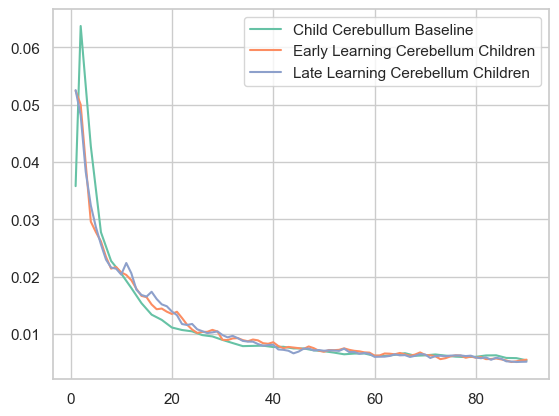

In [47]:
#Lets run a quick visual inspection of the baselines 
# plt.plot(freqs, base_c_avg, label='Adult Cerebullum Baseline')
plt.plot(freqs, base_c_c_avg, label='Child Cerebullum Baseline')
# plt.plot(freqs, base_m_avg, label='Adult Motor Baseline')
# plt.plot(freqs, base_m_c_avg, label='Child Motor Baseline')
plt.plot(freqs, el_c_avg, label='Early Learning Cerebellum Children')
plt.plot(freqs, ll_c_avg, label='Late Learning Cerebellum Children')
plt.legend()
plt.show()

c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu

12 Significant Age differences found at : [1, 2, 16, 17, 18, 19, 20, 21, 24, 25, 29, 34]
0 Significant Condition differences found at : []
0 Significant Interaction differences found at : []


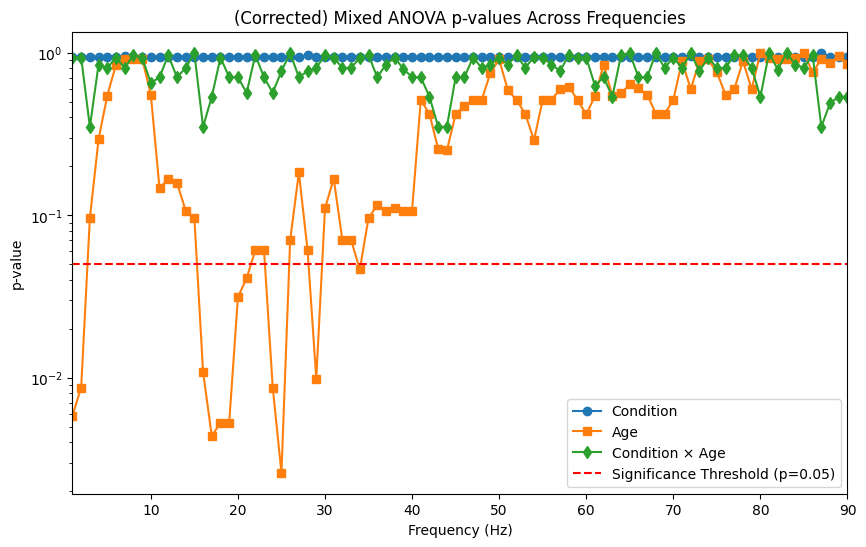

In [30]:
#ANOVA CEREBELLUM 
child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']
adult_subs = ['011', '012', '013','014', '018','019', '021','022','025', '026', '030', '031']

# Assume you have a list of frequencies
pvals_condition = []
pvals_age = []
pvals_interaction = []

#Loop through all 90 frequencies
for i in range(len(freqs)): 

    #Change naming for speed 
    elc = el_cerebellum_normalized_psds_c
    llc = ll_cerebellum_normalized_psds_c
    rlc = rl_cerebellum_normalized_psds_c
    el = el_cerebellum_normalized_psds
    ll = ll_cerebellum_normalized_psds
    rl = rl_cerebellum_normalized_psds

    #Please Ignore my hard coding... I want to store the EL/LL normalized power for each participant
    el_03 = elc[0][i]
    ll_03 = llc[0][i]
    rl_03 = rlc[0][i]
    el_02 = elc[1][i]
    ll_02 = llc[1][i]
    rl_02 = rlc[1][i]
    el_04 = elc[2][i]
    ll_04 = llc[2][i]
    rl_04 = rlc[2][i]
    el_06 = elc[3][i]
    ll_06 = llc[3][i]
    rl_06 = rlc[3][i]
    el_09 = elc[4][i]
    ll_09 = llc[4][i]
    rl_09 = rlc[4][i]
    el_010 = elc[5][i]
    ll_010 = llc[5][i]
    rl_010 = rlc[5][i]
    el_015 = elc[6][i]
    ll_015 = llc[6][i]
    rl_015 = rlc[6][i]
    el_016 = elc[7][i]
    ll_016 = llc[7][i]
    rl_016 = rlc[7][i]
    el_027 = elc[8][i]
    ll_027 = llc[8][i]
    rl_027 = rlc[8][i]
    el_028 = elc[9][i]
    ll_028 = llc[9][i]
    rl_028 = rlc[9][i]
    el_029 = elc[10][i]
    ll_029 = llc[10][i]
    rl_029 = rlc[10][i]

    #Adults
    el_011 = el[0][i]
    ll_011 = ll[0][i]
    rl_011 = rl[0][i]
    el_012 = el[1][i]
    ll_012 = ll[1][i]
    rl_012 = rl[1][i]
    el_013 = el[2][i]
    ll_013 = ll[2][i]
    rl_013 = rl[2][i]
    el_014 = el[3][i]
    ll_014 = ll[3][i]
    rl_014 = rl[3][i]
    el_018 = el[4][i]
    ll_018 = ll[4][i]
    rl_018 = rl[4][i]
    el_019 = el[5][i]
    ll_019 = ll[5][i]
    rl_019 = rl[5][i]
    el_021 = el[6][i]
    ll_021 = ll[6][i]
    rl_021 = rl[6][i]
    el_022 = el[7][i]
    ll_022 = ll[7][i]
    rl_022 = rl[7][i]
    el_025 = el[8][i]
    ll_025 = ll[8][i]
    rl_025 = rl[8][i]
    el_026 = el[9][i]
    ll_026 = ll[9][i]
    rl_026 = rl[9][i]
    el_030 = el[10][i]
    ll_030 = ll[10][i]
    rl_030 = rl[10][i]
    el_031 = el[11][i]
    ll_031 = ll[11][i]
    rl_031 = rl[11][i]

    data = pd.DataFrame({
        'Subject': ['003', '003', '003', '002', '002', '002', '004', '004', '004', '006', '006', '006', '009', '009', '009', '010', '010', '010', 
                    '015', '015', '015', '016', '016', '016', '027', '027', '027', '028', '028', '028', '029', '029', '029',
                    '011', '011', '011', '012', '012', '012', '013', '013', '013', '014', '014', '014', '018', '018', '018', '019', '019', '019', '021', '021', '021', 
                    '022', '022', '022', '025', '025', '025', '026', '026', '026', '030', '030', '030', '031', '031', '031'],
        'Age': ['Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 
                'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child',
                'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 
                'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult'],
        'Condition': ['EL', 'LL', 'RL', 'EL', 'LL', 'RL',  'EL', 'LL', 'RL',  'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 
                      'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL'],
        'Power': [el_03, ll_03, rl_03, el_02, ll_02, rl_02, el_04, ll_04, rl_04, el_06, ll_06, rl_06, el_09, ll_09, rl_09, el_010, ll_010, rl_010, 
                  el_015, ll_015, rl_015, el_016, ll_016, rl_016,  el_027, ll_027, rl_027, el_028, ll_028, rl_028, el_029, ll_029, rl_029, 
                  el_011, ll_011, rl_011, el_012, ll_012, rl_012, el_013, ll_013, rl_013, el_014, ll_014, rl_014, el_018, ll_018, rl_018, el_019, ll_019, rl_019, el_021, ll_021, rl_021, 
                  el_022, ll_022, rl_022, el_025, ll_025, rl_025, el_026, ll_026, rl_026, el_030, ll_030, rl_030, el_031, ll_031, rl_031] 
    })

    # Conducting the mixed ANOVA using pingouin's mixed_anova function
    anova = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=data)
    cond_pv = anova.loc[anova['Source'] == 'Condition', 'p-unc'].values[0]
    age_pv = anova.loc[anova['Source'] == 'Age', 'p-unc'].values[0]
    interaction_pv = anova.loc[anova['Source'] == 'Interaction', 'p-unc'].values[0]

    # Extract p-values
    pvals_condition.append(cond_pv)
    pvals_age.append(age_pv)
    pvals_interaction.append(interaction_pv)

#Correct p-values 
trues_age, pvals_age_cor, _, _ = multipletests(pvals_age, alpha=0.05, method='fdr_bh')
trues_cond, pvals_condition_cor, _, _ = multipletests(pvals_condition, alpha=0.05, method='fdr_bh')
trues_int, pvals_interaction_cor, _, _ = multipletests(pvals_interaction, alpha=0.05, method='fdr_bh')

sig_freqs_cereb_age = []
sig_freqs_cereb_cond = []
sig_freqs_cereb_int = []

age_count_cerb = 0  
cond_count_cerb = 0  
int_count_cerb = 0  

for i in range(len(freqs)):
    if trues_age[i]:
        sig_freqs_cereb_age.append(freqs[i])
        age_count_cerb += 1
    if trues_cond[i]:
        sig_freqs_cereb_cond.append(freqs[i])
        cond_count_cerb += 1
    if trues_int[i]:
        sig_freqs_cereb_int.append(freqs[i])
        int_count_cerb += 1 

print(age_count_cerb, 'Significant Age differences found at :', sig_freqs_cereb_age)
print(cond_count_cerb, 'Significant Condition differences found at :', sig_freqs_cereb_cond)
print(int_count_cerb, 'Significant Interaction differences found at :', sig_freqs_cereb_int)

# Convert to DataFrame
results_df = pd.DataFrame({
    'Frequency (Hz)': freqs,
    'Condition p-value': pvals_condition_cor,
    'Age p-value': pvals_age_cor,
    'Interaction p-value': pvals_interaction_cor
})

# Apply significance threshold (e.g., p < 0.05)
alpha = 0.05
results_df['Sig Condition'] = results_df['Condition p-value'] < alpha
results_df['Sig Age'] = results_df['Age p-value'] < alpha
results_df['Sig Interaction'] = results_df['Interaction p-value'] < alpha

plt.figure(figsize=(10, 6))

# Plot p-values
plt.plot(results_df['Frequency (Hz)'], results_df['Condition p-value'], label='Condition', linestyle='-', marker='o')
plt.plot(results_df['Frequency (Hz)'], results_df['Age p-value'], label='Age', linestyle='-', marker='s')
plt.plot(results_df['Frequency (Hz)'], results_df['Interaction p-value'], label='Condition × Age', linestyle='-', marker='d')

# Add significance threshold line
plt.axhline(y=alpha, color='r', linestyle='--', label='Significance Threshold (p=0.05)')

# Labels & Legend
plt.xlabel('Frequency (Hz)')
plt.ylabel('p-value')
plt.xlim(1,90)
plt.yscale('log')  # Optional: Log-scale for better visualization
plt.title('(Corrected) Mixed ANOVA p-values Across Frequencies')
plt.legend()
#plt.grid(True)

plt.show()


In [31]:
'''SHORT CODE TO FNID BEST WAY OF CORRECTING P-VALUES GENERATED BY 2-WAY ANOVA'''
methods = ['bonferroni', 'sidak', 'holm-sidak', 'holm', 'simes-hochberg', 'hommel', 'fdr_bh', 'fdr_by', 'fdr_tsbh', 'fdr_tsbky']

#Determine best correction method 
for method in methods: 
    trues, corrected, _, _ = multipletests(pvals_age, alpha=0.05, method=method)
    counter = 0
    for i in range(len(trues)):
        if trues[i]:
            #print(i)
            counter += 1

    print(counter, 'significant frequencies with age for the', method, 'method')

5 significant frequencies with age for the bonferroni method
5 significant frequencies with age for the sidak method
6 significant frequencies with age for the holm-sidak method
6 significant frequencies with age for the holm method
6 significant frequencies with age for the simes-hochberg method
6 significant frequencies with age for the hommel method
12 significant frequencies with age for the fdr_bh method
7 significant frequencies with age for the fdr_by method
12 significant frequencies with age for the fdr_tsbh method
12 significant frequencies with age for the fdr_tsbky method


c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu

44 Significant Age differences found at : [1, 2, 3, 4, 5, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 49, 50, 51, 55, 56, 57, 60, 63, 65, 74, 75, 76, 83]
0 Significant Age differences found at : []
0 Significant Age differences found at : []


c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d


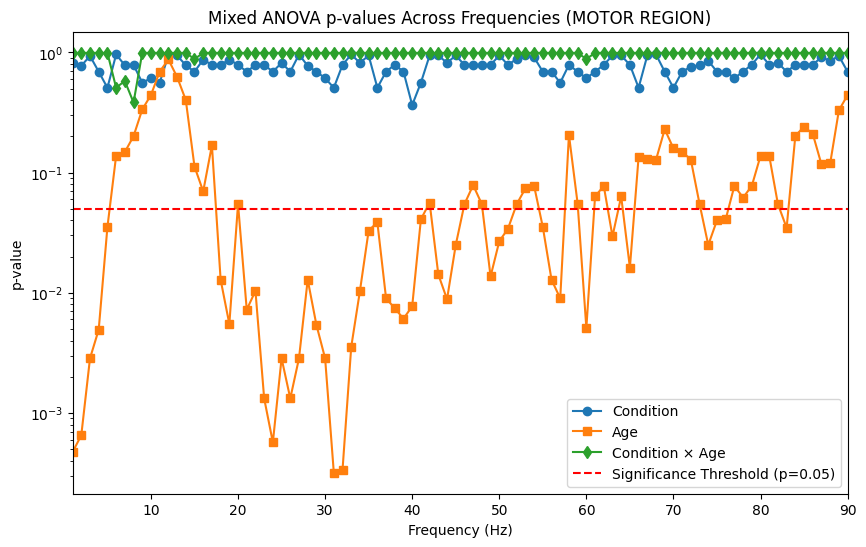

In [32]:
#ANOVA MOTOR 

# Assume you have a list of frequencies
pvals_condition_m = []
pvals_age_m = []
pvals_interaction_m = []

#Loop through all 90 frequencies
for i in range(len(freqs)): 

    #Change naming for speed 
    elc = el_motor_normalized_psds_c
    llc = ll_motor_normalized_psds_c
    rlc = rl_motor_normalized_psds_c
    el = el_motor_normalized_psds
    ll = ll_motor_normalized_psds
    rl = rl_motor_normalized_psds

    #Please Ignore my hard coding... I want to store the EL/LL normalized power for each participant
    el_03 = elc[0][i]
    ll_03 = llc[0][i]
    rl_03 = rlc[0][i]
    el_02 = elc[1][i]
    ll_02 = llc[1][i]
    rl_02 = rlc[1][i]
    el_04 = elc[2][i]
    ll_04 = llc[2][i]
    rl_04 = rlc[2][i]
    el_06 = elc[3][i]
    ll_06 = llc[3][i]
    rl_06 = rlc[3][i]
    el_09 = elc[4][i]
    ll_09 = llc[4][i]
    rl_09 = rlc[4][i]
    el_010 = elc[5][i]
    ll_010 = llc[5][i]
    rl_010 = rlc[5][i]
    el_015 = elc[6][i]
    ll_015 = llc[6][i]
    rl_015 = rlc[6][i]
    el_016 = elc[7][i]
    ll_016 = llc[7][i]
    rl_016 = rlc[7][i]
    el_027 = elc[8][i]
    ll_027 = llc[8][i]
    rl_027 = rlc[8][i]
    el_028 = elc[9][i]
    ll_028 = llc[9][i]
    rl_028 = rlc[9][i]
    el_029 = elc[10][i]
    ll_029 = llc[10][i]
    rl_029 = rlc[10][i]

    #Adults
    el_011 = el[0][i]
    ll_011 = ll[0][i]
    rl_011 = rl[0][i]
    el_012 = el[1][i]
    ll_012 = ll[1][i]
    rl_012 = rl[1][i]
    el_013 = el[2][i]
    ll_013 = ll[2][i]
    rl_013 = rl[2][i]
    el_014 = el[3][i]
    ll_014 = ll[3][i]
    rl_014 = rl[3][i]
    el_018 = el[4][i]
    ll_018 = ll[4][i]
    rl_018 = rl[4][i]
    el_019 = el[5][i]
    ll_019 = ll[5][i]
    rl_019 = rl[5][i]
    el_021 = el[6][i]
    ll_021 = ll[6][i]
    rl_021 = rl[6][i]
    el_022 = el[7][i]
    ll_022 = ll[7][i]
    rl_022 = rl[7][i]
    el_025 = el[8][i]
    ll_025 = ll[8][i]
    rl_025 = rl[8][i]
    el_026 = el[9][i]
    ll_026 = ll[9][i]
    rl_026 = rl[9][i]
    el_030 = el[10][i]
    ll_030 = ll[10][i]
    rl_030 = rl[10][i]
    el_031 = el[11][i]
    ll_031 = ll[11][i]
    rl_031 = rl[11][i]

    data = pd.DataFrame({
        'Subject': ['003', '003', '003', '002', '002', '002', '004', '004', '004', '006', '006', '006', '009', '009', '009', '010', '010', '010', 
                    '015', '015', '015', '016', '016', '016', '027', '027', '027', '028', '028', '028', '029', '029', '029',
                    '011', '011', '011', '012', '012', '012', '013', '013', '013', '014', '014', '014', '018', '018', '018', '019', '019', '019', '021', '021', '021', 
                    '022', '022', '022', '025', '025', '025', '026', '026', '026', '030', '030', '030', '031', '031', '031'],
        'Age': ['Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 
                'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child', 'Child',
                'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 
                'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Adult'],
        'Condition': ['EL', 'LL', 'RL', 'EL', 'LL', 'RL',  'EL', 'LL', 'RL',  'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 
                      'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL', 'EL', 'LL', 'RL'],
        'Power': [el_03, ll_03, rl_03, el_02, ll_02, rl_02, el_04, ll_04, rl_04, el_06, ll_06, rl_06, el_09, ll_09, rl_09, el_010, ll_010, rl_010, 
                  el_015, ll_015, rl_015, el_016, ll_016, rl_016,  el_027, ll_027, rl_027, el_028, ll_028, rl_028, el_029, ll_029, rl_029, 
                  el_011, ll_011, rl_011, el_012, ll_012, rl_012, el_013, ll_013, rl_013, el_014, ll_014, rl_014, el_018, ll_018, rl_018, el_019, ll_019, rl_019, el_021, ll_021, rl_021, 
                  el_022, ll_022, rl_022, el_025, ll_025, rl_025, el_026, ll_026, rl_026, el_030, ll_030, rl_030, el_031, ll_031, rl_031] 
    })

    # Conducting the mixed ANOVA using pingouin's mixed_anova function
    anova = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=data)
    cond_pv = anova.loc[anova['Source'] == 'Condition', 'p-unc'].values[0]
    age_pv = anova.loc[anova['Source'] == 'Age', 'p-unc'].values[0]
    interaction_pv = anova.loc[anova['Source'] == 'Interaction', 'p-unc'].values[0]

    # Extract p-values
    pvals_condition_m.append(cond_pv)
    pvals_age_m.append(age_pv)
    pvals_interaction_m.append(interaction_pv)

#Correct p-values 
trues_age_m, pvals_age_cor_m, _, _ = multipletests(pvals_age_m, alpha=0.05, method='fdr_bh')
trues_cond_m, pvals_condition_cor_m, _, _ = multipletests(pvals_condition_m, alpha=0.05, method='fdr_bh')
trues_int_m, pvals_interaction_cor_m, _, _ = multipletests(pvals_interaction_m, alpha=0.05, method='fdr_bh')

sig_freqs_m_age = []
sig_freqs_m_cond = []
sig_freqs_m_int = []

age_count_m = 0  
cond_count_m = 0  
int_count_m = 0  

for i in range(len(freqs)):
    if trues_age_m[i]:
        sig_freqs_m_age.append(freqs[i])
        age_count_m += 1
    if trues_cond_m[i]:
        sig_freqs_m_cond.append(freqs[i])
        cond_count_m += 1
    if trues_int_m[i]:
        sig_freqs_m_int.append(freqs[i])
        int_count_m += 1 

print(age_count_m, 'Significant Age differences found at :', sig_freqs_m_age)
print(cond_count_m, 'Significant Age differences found at :', sig_freqs_m_cond)
print(int_count_m, 'Significant Age differences found at :', sig_freqs_m_int)

# Convert to DataFrame
results_df = pd.DataFrame({
    'Frequency (Hz)': freqs,
    'Condition p-value': pvals_condition_cor_m,
    'Age p-value': pvals_age_cor_m,
    'Interaction p-value': pvals_interaction_cor_m
})

# Apply significance threshold (e.g., p < 0.05)
alpha = 0.05
results_df['Sig Condition'] = results_df['Condition p-value'] < alpha
results_df['Sig Age'] = results_df['Age p-value'] < alpha
results_df['Sig Interaction'] = results_df['Interaction p-value'] < alpha

plt.figure(figsize=(10, 6))

# Plot p-values
plt.plot(results_df['Frequency (Hz)'], results_df['Condition p-value'], label='Condition', linestyle='-', marker='o')
plt.plot(results_df['Frequency (Hz)'], results_df['Age p-value'], label='Age', linestyle='-', marker='s')
plt.plot(results_df['Frequency (Hz)'], results_df['Interaction p-value'], label='Condition × Age', linestyle='-', marker='d')

# Add significance threshold line
plt.axhline(y=alpha, color='r', linestyle='--', label='Significance Threshold (p=0.05)')

# Labels & Legend
plt.xlabel('Frequency (Hz)')
plt.ylabel('p-value')
plt.xlim(1,90)
plt.yscale('log')  # Optional: Log-scale for better visualization
plt.title('Mixed ANOVA p-values Across Frequencies (MOTOR REGION)')
plt.legend()
#plt.grid(True)

plt.show()

In [33]:
#Add 1/f plot
one_over_f = []
for freq in freqs: 
    one_over_f.append (1/freq)

s1 = np.sum(one_over_f)

for i in range(len(one_over_f)): 
    one_over_f[i] = 100 * (one_over_f[i] / s1)

print(one_over_f)

[19.67508330212968, 9.83754165106484, 6.558361100709892, 4.91877082553242, 3.935016660425936, 3.279180550354946, 2.8107261860185253, 2.45938541276621, 2.1861203669032974, 1.967508330212968, 1.7886439365572433, 1.639590275177473, 1.5134679463176677, 1.4053630930092627, 1.3116722201419784, 1.229692706383105, 1.1573578413017458, 1.0930601834516487, 1.0355307001120881, 0.983754165106484, 0.9369087286728417, 0.8943219682786216, 0.8554384044404207, 0.8197951375887365, 0.7870033320851871, 0.7567339731588338, 0.7287067889677659, 0.7026815465046313, 0.6784511483492992, 0.6558361100709892, 0.6346801065203121, 0.6148463531915525, 0.5962146455190812, 0.5786789206508729, 0.562145237203705, 0.5465300917258243, 0.531759008165667, 0.5177653500560441, 0.5044893154392225, 0.491877082553242, 0.4798800805397483, 0.46845436433642085, 0.4575600767937134, 0.4471609841393108, 0.43722407338065955, 0.42771920222021037, 0.41861879366233357, 0.40989756879436823, 0.4015323122883607, 0.39350166604259357, 0.38578594

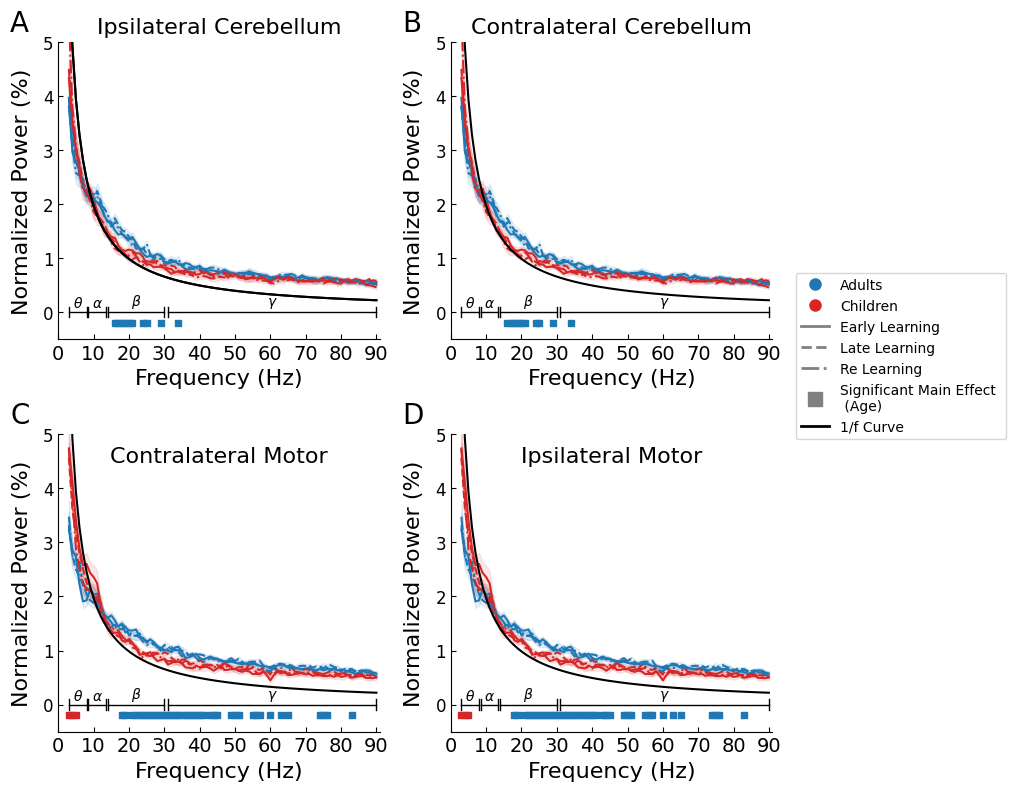

In [ ]:
'''THIS GRAPH IS NOW MISLEADING, I WANTED TO SHOW 4 DIFFERENT BRAIN REGIONS, IN ORDER TO DO SO YOU MUST SAVE DATA FROM TWO OF THE REGIONS 
AND READ IT IN BEFORE MAKING THIS PLOT, OTHERWISE YOU ARE SHOWING THE SAME TWO REGIONS (MOTOR/CEREBELLAR) THAT THIS SCRIPT GENERATES'''

color_adult = 'tab:blue'
color_child = 'tab:red'

freqs = np.linspace(1,90,90)
freqs = freqs[2:] #Begin from 3Hz 

#Add Frequency Bands
bands = [(3, 8), (8, 13), (13, 30), (30, 90)]
band_colors = ['gray', 'gray', 'gray', 'gray']

# Create subplots: 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# List of axes for easy reference
ax1, ax2, ax3, ax4 = axes.flatten()

yticks = [0, 1, 2, 3, 4, 5]
xticks = [0,10,20,30,40,50,60,70,80,90]

legend_handles = [
    mlines.Line2D([], [], color=color_adult, marker='o', linestyle='None', markersize=8, label='Adults'),
    mlines.Line2D([], [], color=color_child, marker='o', linestyle='None', markersize=8, label='Children'),
    mlines.Line2D([], [], color='grey', linestyle='-', linewidth=2, label='Early Learning'),
    mlines.Line2D([], [], color='grey', linestyle='--', linewidth=2, label='Late Learning'),
    mlines.Line2D([], [], color='grey', linestyle='-.', linewidth=2, label='Re Learning'),  
    mlines.Line2D([], [], color='grey', marker='s', linestyle='None', markersize=10, label='Significant Main Effect \n (Age)'),
    mlines.Line2D([], [], color='black', linewidth=2, label='1/f Curve')
    #mlines.Line2D([], [], color='yellow', marker='s', linestyle='None', markersize=10, label='Significant Secondary Effect \n (Condition)'),
]

# ---- PLOT 1: Cerebellum EL vs LL ----
ax1.plot(freqs, 100 * np.mean(g_el_cerebellum_normalized_psds, axis=0)[2:], label='EL Adults', color=color_adult)
ax1.plot(freqs, 100 * np.mean(g_el_cerebellum_normalized_psds_c, axis=0)[2:], label='EL Children', color=color_child)
ax1.plot(freqs, 100 * np.mean(g_ll_cerebellum_normalized_psds, axis=0)[2:], label='LL Adults', color=color_adult, linestyle='--')
ax1.plot(freqs, 100 * np.mean(g_ll_cerebellum_normalized_psds_c, axis=0)[2:], label='LL Children', color=color_child, linestyle='--')
ax1.plot(freqs, 100 * np.mean(g_rl_cerebellum_normalized_psds, axis=0)[2:], label='RL Adults', color=color_adult, linestyle='-.')
ax1.plot(freqs, 100 * np.mean(g_rl_cerebellum_normalized_psds_c, axis=0)[2:], label='RL Children', color=color_child, linestyle='-.')

ax1.fill_between(freqs, 100 * np.mean(g_el_cerebellum_normalized_psds, axis=0)[2:] - 100 * g_std_el_c[2:],
                 100 * np.mean(g_el_cerebellum_normalized_psds, axis=0)[2:] + 100 * g_std_el_c[2:], alpha=0.1, color=color_adult)
ax1.fill_between(freqs, 100 * np.mean(g_ll_cerebellum_normalized_psds, axis=0)[2:] - 100 * g_std_ll_c[2:],
                 100 * np.mean(g_ll_cerebellum_normalized_psds, axis=0)[2:] + 100 * g_std_ll_c[2:], alpha=0.1, color=color_adult)
ax1.fill_between(freqs, 100 * np.mean(g_el_cerebellum_normalized_psds_c, axis=0)[2:] - 100 * g_std_el_c_c[2:],
                 100 * np.mean(g_el_cerebellum_normalized_psds_c, axis=0)[2:] + 100 * g_std_el_c_c[2:], alpha=0.1, color=color_child)
ax1.fill_between(freqs, 100 * np.mean(g_ll_cerebellum_normalized_psds_c, axis=0)[2:] - 100 * g_std_ll_c_c[2:],
                 100 * np.mean(g_ll_cerebellum_normalized_psds_c, axis=0)[2:] + 100 * g_std_ll_c_c[2:], alpha=0.1, color=color_child)
ax1.fill_between(freqs, 100 * np.mean(g_rl_cerebellum_normalized_psds, axis=0)[2:] - 100 * g_std_rl_c[2:],
                 100 * np.mean(g_rl_cerebellum_normalized_psds, axis=0)[2:] + 100 * g_std_rl_c[2:], alpha=0.1, color=color_adult)
ax1.fill_between(freqs, 100 * np.mean(g_rl_cerebellum_normalized_psds_c, axis=0)[2:] - 100 * g_std_rl_c_c[2:],
                 100 * np.mean(g_rl_cerebellum_normalized_psds_c, axis=0)[2:] + 100 * g_std_rl_c_c[2:], alpha=0.1, color=color_child)

for freq in g_sig_freqs_cereb_age[2:]:
    freq_idx = np.argmin(np.abs(freqs - freq))  # Find the closest index
    adult_power = np.mean(g_el_cerebellum_normalized_psds, axis=0)[freq_idx]
    child_power = np.mean(g_el_cerebellum_normalized_psds_c, axis=0)[freq_idx]
    color = color_adult if adult_power > child_power else color_child
    ax1.scatter(freq, -0.2, marker='s', s=16, color=color)

# ax1.scatter(g_sig_freqs_cereb_age[2:], np.full(len(g_sig_freqs_cereb_age[2:]), -0.2), label='Significant Frequencies', marker='s', s=16, color='black')
# ax1.scatter(g_sig_freqs_cereb_cond, np.full(len(g_sig_freqs_cereb_cond), -0.1), label='Significant Conditions', marker='s', s=16, color='yellow')
# ax1.scatter(g_sig_freqs_cereb_int, np.full(len(g_sig_freqs_cereb_int), 0), label='Significant interactions', marker='s', s=16, color='green')

ax1.set_xlim(3, 91)
ax1.set_ylim(-0.5, 5)
ax1.set_yticks(yticks)
ax1.set_xticks(xticks)
ax1.set_title('Ipsilateral Cerebellum', fontsize=16)
ax1.set_xlabel('Frequency (Hz)', fontsize=16)
#ax1.legend(handles=legend_handles, frameon=False, fontsize=10, loc='best', bbox_to_anchor=(1.25, 0.55))
ax1.set_ylabel('Normalized Power (%)', fontsize=16)

# ---- PLOT 2: Cerebellum EL vs RL ----
ax2.plot(freqs, 100 * np.mean(el_cerebellum_normalized_psds, axis=0)[2:], label='EL Adults', color=color_adult)
ax2.plot(freqs, 100 * np.mean(el_cerebellum_normalized_psds_c, axis=0)[2:], label='EL Children', color=color_child)
ax2.plot(freqs, 100 * np.mean(ll_cerebellum_normalized_psds, axis=0)[2:], label='LL Adults', color=color_adult, linestyle='--')
ax2.plot(freqs, 100 * np.mean(ll_cerebellum_normalized_psds_c, axis=0)[2:], label='LL Children', color=color_child, linestyle='--')
ax2.plot(freqs, 100 * np.mean(rl_cerebellum_normalized_psds, axis=0)[2:], label='RL Adults', color=color_adult, linestyle='-.')
ax2.plot(freqs, 100 * np.mean(rl_cerebellum_normalized_psds_c, axis=0)[2:], label='RL Children', color=color_child, linestyle='-.')

ax2.fill_between(freqs, 100 * np.mean(el_cerebellum_normalized_psds, axis=0)[2:] - 100 * el_c_std[2:],
                 100 * np.mean(el_cerebellum_normalized_psds, axis=0)[2:] + 100 * el_c_std[2:], alpha=0.1, color=color_adult)
ax2.fill_between(freqs, 100 * np.mean(ll_cerebellum_normalized_psds, axis=0)[2:] - 100 * ll_c_std[2:],
                 100 * np.mean(ll_cerebellum_normalized_psds, axis=0)[2:] + 100 * ll_c_std[2:], alpha=0.1, color=color_adult)
ax2.fill_between(freqs, 100 * np.mean(rl_cerebellum_normalized_psds, axis=0)[2:] - 100 * rl_c_std[2:],
                 100 * np.mean(rl_cerebellum_normalized_psds, axis=0)[2:] + 100 * rl_c_std[2:], alpha=0.1, color=color_adult)
ax2.fill_between(freqs, 100 * np.mean(el_cerebellum_normalized_psds_c, axis=0)[2:] - 100 * el_c_c_std[2:],
                 100 * np.mean(el_cerebellum_normalized_psds_c, axis=0)[2:] + 100 * el_c_c_std[2:], alpha=0.1, color=color_child)
ax2.fill_between(freqs, 100 * np.mean(ll_cerebellum_normalized_psds_c, axis=0)[2:] - 100 * ll_c_c_std[2:],
                 100 * np.mean(ll_cerebellum_normalized_psds_c, axis=0)[2:] + 100 * ll_c_c_std[2:], alpha=0.1, color=color_child)
ax2.fill_between(freqs, 100 * np.mean(rl_cerebellum_normalized_psds_c, axis=0)[2:] - 100 * rl_c_c_std[2:],
                 100 * np.mean(rl_cerebellum_normalized_psds_c, axis=0)[2:] + 100 * rl_c_c_std[2:], alpha=0.1, color=color_child)

for freq in sig_freqs_cereb_age[2:]:
    freq_idx = np.argmin(np.abs(freqs - freq))  # Find the closest index
    adult_power = np.mean(el_cerebellum_normalized_psds, axis=0)[freq_idx]
    child_power = np.mean(el_cerebellum_normalized_psds_c, axis=0)[freq_idx]
    color = color_adult if adult_power > child_power else color_child
    ax2.scatter(freq, -0.2, marker='s', s=16, color=color)

# ax2.scatter(sig_freqs_cereb_age[2:], np.full(len(sig_freqs_cereb_age[2:]), -0.2), label='Significant Frequencies', marker='s', s=16, color='black')
# ax2.scatter(sig_freqs_cereb_cond, np.full(len(sig_freqs_cereb_cond), -0.1), label='Significant Conditions', marker='s', s=16, color='yellow') #HAS ONE!
# ax2.scatter(sig_freqs_cereb_int, np.full(len(sig_freqs_cereb_int), 0), label='Significant interactions', marker='s', s=16, color='green')

ax2.set_xlim(3, 91)
ax2.set_ylim(-0.5, 5)
ax2.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_title('Contralateral Cerebellum', fontsize=16)
ax2.set_xlabel('Frequency (Hz)', fontsize=16)
ax2.set_ylabel('Normalized Power (%)', fontsize=16)

# ---- PLOT 3: Motor Cortex EL vs LL ----
ax3.plot(freqs, 100 * np.mean(g_el_motor_normalized_psds, axis=0)[2:], label='EL Adults', color=color_adult)
ax3.plot(freqs, 100 * np.mean(g_el_motor_normalized_psds_c, axis=0)[2:], label='EL Children', color=color_child)
ax3.plot(freqs, 100 * np.mean(g_ll_motor_normalized_psds, axis=0)[2:], label='LL Adults', color=color_adult, linestyle='--')
ax3.plot(freqs, 100 * np.mean(g_ll_motor_normalized_psds_c, axis=0)[2:], label='LL Children', color=color_child, linestyle='--')
ax3.plot(freqs, 100 * np.mean(g_rl_motor_normalized_psds, axis=0)[2:], label='RL Adults', color=color_adult, linestyle='-.')
ax3.plot(freqs, 100 * np.mean(g_rl_motor_normalized_psds_c, axis=0)[2:], label='RL Children', color=color_child, linestyle='-.')

ax3.fill_between(freqs, 100 * np.mean(g_el_motor_normalized_psds, axis=0)[2:] - 100 * g_el_m_std[2:],
                 100 * np.mean(g_el_motor_normalized_psds, axis=0)[2:] + 100 * g_el_m_std[2:], alpha=0.1, color=color_adult)
ax3.fill_between(freqs, 100 * np.mean(g_ll_motor_normalized_psds, axis=0)[2:] - 100 * g_ll_m_std[2:],
                 100 * np.mean(g_ll_motor_normalized_psds, axis=0)[2:] + 100 * g_ll_m_std[2:], alpha=0.1, color=color_adult)
ax3.fill_between(freqs, 100 * np.mean(g_el_motor_normalized_psds_c, axis=0)[2:] - 100 * g_el_m_c_std[2:],
                 100 * np.mean(g_el_motor_normalized_psds_c, axis=0)[2:] + 100 * g_el_m_c_std[2:], alpha=0.1, color=color_child)
ax3.fill_between(freqs, 100 * np.mean(g_ll_motor_normalized_psds_c, axis=0)[2:] - 100 * g_ll_m_c_std[2:],
                 100 * np.mean(g_ll_motor_normalized_psds_c, axis=0)[2:] + 100 * g_ll_m_c_std[2:], alpha=0.1, color=color_child)
ax3.fill_between(freqs, 100 * np.mean(g_rl_motor_normalized_psds, axis=0)[2:] - 100 * g_rl_m_std[2:],
                 100 * np.mean(g_rl_motor_normalized_psds, axis=0)[2:] + 100 * g_rl_m_std[2:], alpha=0.1, color=color_adult)
ax3.fill_between(freqs, 100 * np.mean(g_rl_motor_normalized_psds_c, axis=0)[2:] - 100 * g_rl_m_c_std[2:],
                 100 * np.mean(g_rl_motor_normalized_psds_c, axis=0)[2:] + 100 * g_rl_m_c_std[2:], alpha=0.1, color=color_child)

for freq in g_sig_freqs_m_age[2:]:
    freq_idx = np.argmin(np.abs(freqs - freq))  # Find the closest index
    adult_power = np.mean(g_el_motor_normalized_psds, axis=0)[freq_idx]
    child_power = np.mean(g_el_motor_normalized_psds_c, axis=0)[freq_idx]
    color = color_adult if adult_power > child_power else color_child
    ax3.scatter(freq, -0.2, marker='s', s=16, color=color)

# ax3.scatter(g_sig_freqs_m_age[2:], np.full(len(g_sig_freqs_m_age[2:]), -0.2), label='Significant Frequencies', marker='s', s=16, color='black')
# ax3.scatter(g_sig_freqs_m_cond, np.full(len(g_sig_freqs_m_cond), -0.1), label='Significant Conditions', marker='s', s=16, color='yellow')
# ax3.scatter(g_sig_freqs_m_int, np.full(len(g_sig_freqs_m_int), 0), label='Significant interactions', marker='s', s=16, color='green')

ax3.set_xlim(3, 91)
ax3.set_ylim(-0.5, 5)
ax3.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_title('Contralateral Motor', fontsize=16, y=0.88)
ax3.set_xlabel('Frequency (Hz)', fontsize=16)
ax3.set_ylabel('Normalized Power (%)', fontsize=16)

# ---- PLOT 4: Motor Cortex EL vs RL ----
ax4.plot(freqs, 100 * np.mean(el_motor_normalized_psds, axis=0)[2:], label='EL Adults', color=color_adult)
ax4.plot(freqs, 100 * np.mean(el_motor_normalized_psds_c, axis=0)[2:], label='EL Children', color=color_child)
ax4.plot(freqs, 100 * np.mean(ll_motor_normalized_psds, axis=0)[2:], label='LL Adults', color=color_adult, linestyle='--')
ax4.plot(freqs, 100 * np.mean(ll_motor_normalized_psds_c, axis=0)[2:], label='LL Children', color=color_child, linestyle='--')
ax4.plot(freqs, 100 * np.mean(rl_motor_normalized_psds, axis=0)[2:], label='RL Adults', color=color_adult, linestyle='-.')
ax4.plot(freqs, 100 * np.mean(rl_motor_normalized_psds_c, axis=0)[2:], label='RL Children', color=color_child, linestyle='-.')

ax4.fill_between(freqs, 100 * np.mean(el_motor_normalized_psds, axis=0)[2:] - 100 * el_m_std[2:],
                 100 * np.mean(el_motor_normalized_psds, axis=0)[2:] + 100 * el_m_std[2:], alpha=0.1, color=color_adult)
ax4.fill_between(freqs, 100 * np.mean(rl_motor_normalized_psds, axis=0)[2:] - 100 * rl_m_std[2:],
                 100 * np.mean(rl_motor_normalized_psds, axis=0)[2:] + 100 * rl_m_std[2:], alpha=0.1, color=color_adult)
ax4.fill_between(freqs, 100 * np.mean(el_motor_normalized_psds_c, axis=0)[2:] - 100 * el_m_c_std[2:],
                 100 * np.mean(el_motor_normalized_psds_c, axis=0)[2:] + 100 * el_m_c_std[2:], alpha=0.1, color=color_child)
ax4.fill_between(freqs, 100 * np.mean(rl_motor_normalized_psds_c, axis=0)[2:] - 100 * rl_m_c_std[2:],
                 100 * np.mean(rl_motor_normalized_psds_c, axis=0)[2:] + 100 * rl_m_c_std[2:], alpha=0.1, color=color_child)
ax4.fill_between(freqs, 100 * np.mean(ll_motor_normalized_psds, axis=0)[2:] - 100 * ll_m_std[2:],
                 100 * np.mean(ll_motor_normalized_psds, axis=0)[2:] + 100 * ll_m_std[2:], alpha=0.1, color=color_adult)
ax4.fill_between(freqs, 100 * np.mean(ll_motor_normalized_psds_c, axis=0)[2:] - 100 * ll_m_c_std[2:],
                 100 * np.mean(ll_motor_normalized_psds_c, axis=0)[2:] + 100 * ll_m_c_std[2:], alpha=0.1, color=color_child)

for freq in sig_freqs_m_age[2:]:
    freq_idx = np.argmin(np.abs(freqs - freq))  # Find the closest index
    adult_power = np.mean(el_motor_normalized_psds, axis=0)[freq_idx]
    child_power = np.mean(el_motor_normalized_psds_c, axis=0)[freq_idx]
    color = color_adult if adult_power > child_power else color_child
    ax4.scatter(freq, -0.2, marker='s', s=16, color=color)

# ax4.scatter(sig_freqs_m_age[2:], np.full(len(sig_freqs_m_age[2:]), -0.2), label='Significant Frequencies', marker='s', s=16, color='black')
# ax4.scatter(sig_freqs_m_cond, np.full(len(sig_freqs_m_cond), -0.1), label='Significant Conditions', marker='s', s=16, color='yellow')
# ax4.scatter(sig_freqs_m_int, np.full(len(sig_freqs_m_int), 0), label='Significant Interactions', marker='s', s=16, color='green')

ax4.set_xlim(3, 91)
ax4.set_ylim(-0.5, 5)
ax4.set_yticks(yticks)
ax4.set_xticks(xticks)
ax4.set_title('Ipsilateral Motor', fontsize=16, y=0.88)
ax4.set_xlabel('Frequency (Hz)', fontsize=16)
ax4.set_ylabel('Normalized Power (%)', fontsize=16)

# Apply consistent formatting
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=14, direction='in', top=False)
    ax.tick_params(axis='y', labelsize=12, direction='in', right=False)

for ax, label in zip([ax1, ax2, ax3, ax4], ['A', 'B', 'C', 'D']):
    ax.text(-0.15, 1.11, label, transform=ax.transAxes, fontsize=20, va='top', ha='left')

for ax in [ax1, ax2, ax3, ax4]:  # Apply to all subplots
    ax.xaxis.labelpad = 4  # Increase spacing for x-axis label
    ax.yaxis.labelpad = 8  # Increase spacing for y-axis label
    ax.plot(freqs, one_over_f[2:], color='black')

# Define band positions and labels
band_labels = [r'$\theta$', r'$\alpha$', r'$\beta$', r'$\gamma$']
band_positions = [(3, 8), (8.5, 13.5), (14, 30), (31, 90)]  # Added small spacing between bands
x_offsets = [-1.5, 0, 1.5, 3]  # Slightly stagger x positions for labels
y_offset = 0  # Keep the y-position constant
tick_length = 0.1  # Length of vertical ticks at band edges

# Add horizontal bars and ticks for each frequency band
for (start, end), label, x_offset in zip(band_positions, band_labels, x_offsets):
    for ax in [ax1, ax2, ax3, ax4]:  # Apply to all subplots

        # Draw horizontal line (band bar)
        ax.plot([start, end], [y_offset, y_offset], color='black', linewidth=1)  
        
        # Add vertical ticks at the ends of the bar
        ax.plot([start, start], [y_offset - tick_length, y_offset + tick_length], color='black', linewidth=1)
        ax.plot([end, end], [y_offset - tick_length, y_offset + tick_length], color='black', linewidth=1)

        # Add frequency band label, staggered slightly in x
        ax.text(((start + end) / 2) , y_offset + 0.03, label, ha='center', va='bottom', fontsize=10)

apply_loglog = False

fig.legend(handles=legend_handles, frameon=True, fontsize=10, loc='center left', bbox_to_anchor=(0.99, 0.55))

if apply_loglog:
    for ax in [ax1, ax2, ax3, ax4]:  
        #ax.set_xscale('log')
        ax.set_yscale('log')

    # # Adjust tick labels for better readability
    # for ax in [ax1, ax2, ax3, ax4]:  
    #     ax.xaxis.set_major_formatter(plt.ticker.ScalarFormatter())
    #     ax.yaxis.set_major_formatter(plt.ticker.ScalarFormatter())
    #     ax.tick_params(axis='x', which='both', direction='in', length=5)
    #     ax.tick_params(axis='y', which='both', direction='in', length=5)


ax1.plot(freqs, one_over_f[2:], color='black')

plt.savefig(op.join('psd_data', "power.png"), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


Running FOOOFGroup across 12 power spectra.

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Running FOOOFGroup across 11 power spectra.

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



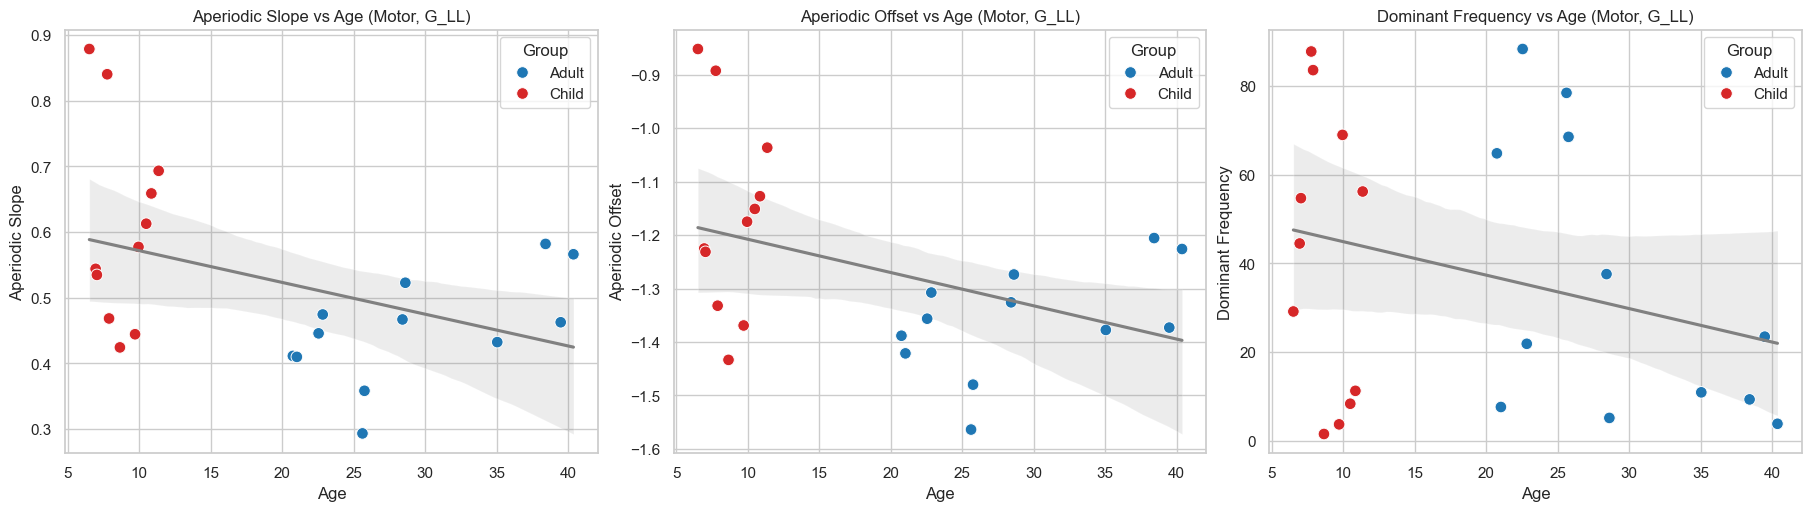

In [36]:
freqs = np.linspace(1,90,90)

# === CONFIGURATION ===
brain_region = 'motor'   # 'motor' or 'cerebellum'
condition = 'g_ll'         # 'el' (early learning) or 'll' (late learning)
palette = {'Adult': 'tab:blue', 'Child': 'tab:red'}

# === Variable Naming Convention ===
adult_var_name = f"{condition}_{brain_region}_normalized_psds"
child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
label_title = f"{brain_region.capitalize()} Region - {'Early' if condition == 'el' else 'Late'} Learning"

# === Load the Variables Dynamically ===
adult_data = globals()[adult_var_name]
child_data = globals()[child_var_name]

# === FOOOF Parameters ===
fg_adult = FOOOFGroup(peak_width_limits=[1.0, 8.0], max_n_peaks=4, 
                      min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed')
fg_adult.fit(freqs, np.vstack(adult_data))

fg_child = FOOOFGroup(peak_width_limits=[1.0, 8.0], max_n_peaks=4, 
                      min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed')
fg_child.fit(freqs, np.vstack(child_data))

# === Helper Function ===
def get_dominant_freqs(fg):
    freqs = []
    for fm in fg:
        peaks = fm.peak_params
        if len(peaks) > 0:
            freqs.append(peaks[np.argmax(peaks[:, 1])][0])
        else:
            freqs.append(np.nan)
    return freqs

# === Age Lists ===
ages_adults = [39.49, 28.42, 25.62, 40.38, 38.43, 25.76, 28.62, 35.05, 22.55, 20.75, 21.03, 22.84]
ages_child  = [6.95, 10.85, 10.49, 7.04, 7.89, 9.71, 7.76, 11.36, 8.65, 6.51, 9.95]

# === Combine into Single DataFrame ===
df = pd.DataFrame({
    'Age': ages_adults + ages_child,
    'Aperiodic Slope': np.concatenate([
        fg_adult.get_params('aperiodic_params', 'exponent'),
        fg_child.get_params('aperiodic_params', 'exponent')
    ]),
    'Aperiodic Offset': np.concatenate([
        fg_adult.get_params('aperiodic_params', 'offset'),
        fg_child.get_params('aperiodic_params', 'offset')
    ]),
    'Dominant Frequency': np.concatenate([
        get_dominant_freqs(fg_adult),
        get_dominant_freqs(fg_child)
    ]),
    'Group': ['Adult'] * len(ages_adults) + ['Child'] * len(ages_child)
})

# --- Plot All Metrics in Adjacent Subplots ---
sns.set(style='whitegrid', context='notebook', palette='Set2')
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Aperiodic Slope
sns.regplot(data=df, x='Age', y='Aperiodic Slope', scatter=False, color='gray', ax=axs[0])
sns.scatterplot(data=df, x='Age', y='Aperiodic Slope', hue='Group', s=70, palette=palette, ax=axs[0])
axs[0].set_title(f'Aperiodic Slope vs Age ({brain_region.capitalize()}, {condition.upper()})')

# Aperiodic Offset
sns.regplot(data=df, x='Age', y='Aperiodic Offset', scatter=False, color='gray', ax=axs[1])
sns.scatterplot(data=df, x='Age', y='Aperiodic Offset', hue='Group', s=70, palette=palette,  ax=axs[1])
axs[1].set_title(f'Aperiodic Offset vs Age ({brain_region.capitalize()}, {condition.upper()})')

# Dominant Frequency
sns.regplot(data=df, x='Age', y='Dominant Frequency', scatter=False, color='gray', ax=axs[2])
sns.scatterplot(data=df, x='Age', y='Dominant Frequency', hue='Group', s=70, palette=palette,  ax=axs[2])
axs[2].set_title(f'Dominant Frequency vs Age ({brain_region.capitalize()}, {condition.upper()})')

plt.show()


Running FOOOFGroup across 12 power spectra.

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Running FOOOFGroup across 11 power spectra.

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_23324\2483962862.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=cf_df, x='Group', y='Center Frequency', jitter=True,


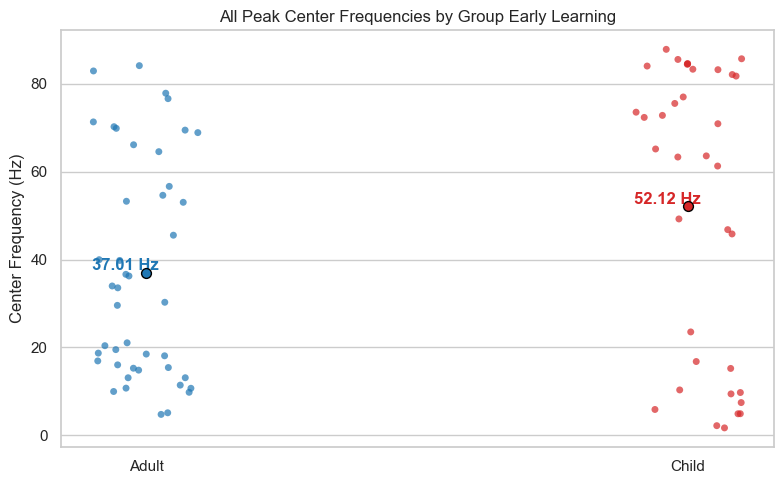

In [39]:
# === CONFIGURATION ===
brain_region = 'cerebellum'   # 'motor' or 'cerebellum'
condition = 'g_el'         # 'el' (early learning) or 'll' (late learning)
palette = {'Adult': 'tab:blue', 'Child': 'tab:red'}

if condition == 'g_ll':
    condition_title = 'Late Learning'
else:
    condition_title = 'Early Learning'

# === Variable Naming Convention ===
adult_var_name = f"{condition}_{brain_region}_normalized_psds"
child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
label_title = f"{brain_region.capitalize()} Region - {'Early' if condition == 'el' else 'Late'} Learning"

# === Load the Variables Dynamically ===
adult_data = globals()[adult_var_name]
child_data = globals()[child_var_name]

# === FOOOF Parameters ===
fg_adult = FOOOFGroup(peak_width_limits=[1.0, 8.0], max_n_peaks=4, 
                      min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed')
fg_adult.fit(freqs, np.vstack(adult_data))

fg_child = FOOOFGroup(peak_width_limits=[1.0, 8.0], max_n_peaks=4, 
                      min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed')
fg_child.fit(freqs, np.vstack(child_data))

# --- Extract all peak CFs from a FOOOFGroup ---
def extract_all_peak_cfs(fg, group_label):
    all_cfs = []
    all_groups = []
    for fm in fg:
        for peak in fm.peak_params:
            all_cfs.append(peak[0])  # center frequency
            all_groups.append(group_label)
    return all_cfs, all_groups

# --- Get CFs for each group ---
adult_cfs, adult_groups = extract_all_peak_cfs(fg_adult, 'Adult')
child_cfs, child_groups = extract_all_peak_cfs(fg_child, 'Child')

# --- Combine into a dataframe ---
cf_df = pd.DataFrame({
    'Center Frequency': adult_cfs + child_cfs,
    'Group': adult_groups + child_groups
})

# --- Compute means ---
mean_adult = np.mean(adult_cfs)
mean_child = np.mean(child_cfs)

# --- Plot ---
plt.figure(figsize=(8, 5))
sns.stripplot(data=cf_df, x='Group', y='Center Frequency', jitter=True,
              palette={'Adult': 'tab:blue', 'Child': 'tab:red'}, alpha=0.7)

# Plot average points
plt.scatter(['Adult'], [mean_adult], color='tab:blue', edgecolor='black', s=50, marker='o', zorder=5)
plt.scatter(['Child'], [mean_child], color='tab:red', edgecolor='black', s=50, marker='o', zorder=5)

# Annotate the mean values
plt.text(-0.1, mean_adult + 0.5, f'{mean_adult:.2f} Hz', color='tab:blue', weight='bold')
plt.text(0.9, mean_child + 0.5, f'{mean_child:.2f} Hz', color='tab:red', weight='bold')

plt.title(f'All Peak Center Frequencies by Group {condition_title}')
plt.ylabel('Center Frequency (Hz)')
plt.xlabel('')
plt.tight_layout()
plt.show()



(12, 90)

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 1.00 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                         

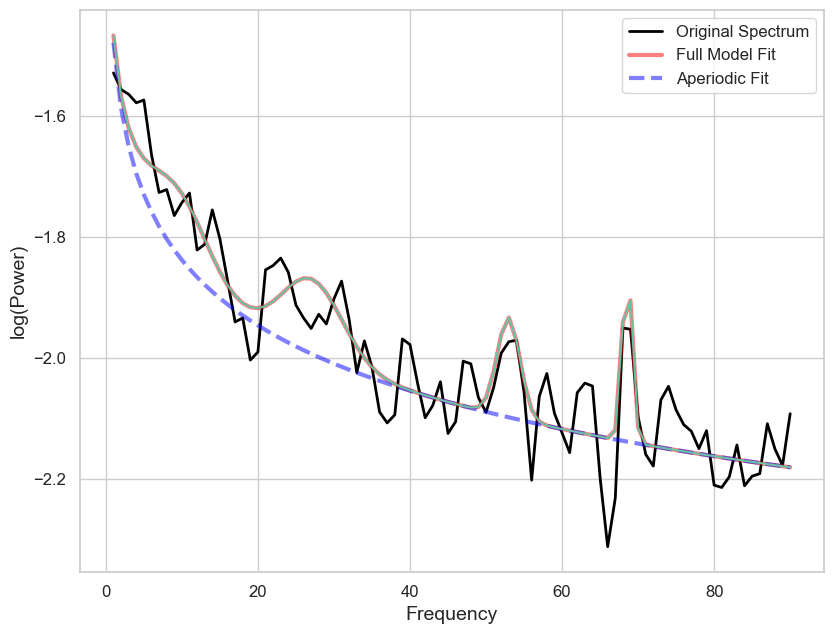

In [40]:
#FOOF analysis 
from fooof import FOOOF
from fooof import FOOOFGroup
freqs = np.linspace(1, 90, 90)
freq_range = [1, 90]
print(np.shape(g_el_motor_normalized_psds))

# Initialize FOOOF object
fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4, min_peak_height=0.1,
           peak_threshold=2.0, aperiodic_mode='fixed')

fm.fit(freqs, g_ll_motor_normalized_psds[0], freq_range)
# Define frequency range across which to model the spectrum
freq_range = [1, 90]

# # Model the power spectrum with FOOOF, and print out a report
fm.report(freqs, g_ll_motor_normalized_psds[5], freq_range)

#print(fm.fooofed_spectrum_)

plt.plot(freqs, fm.fooofed_spectrum_)

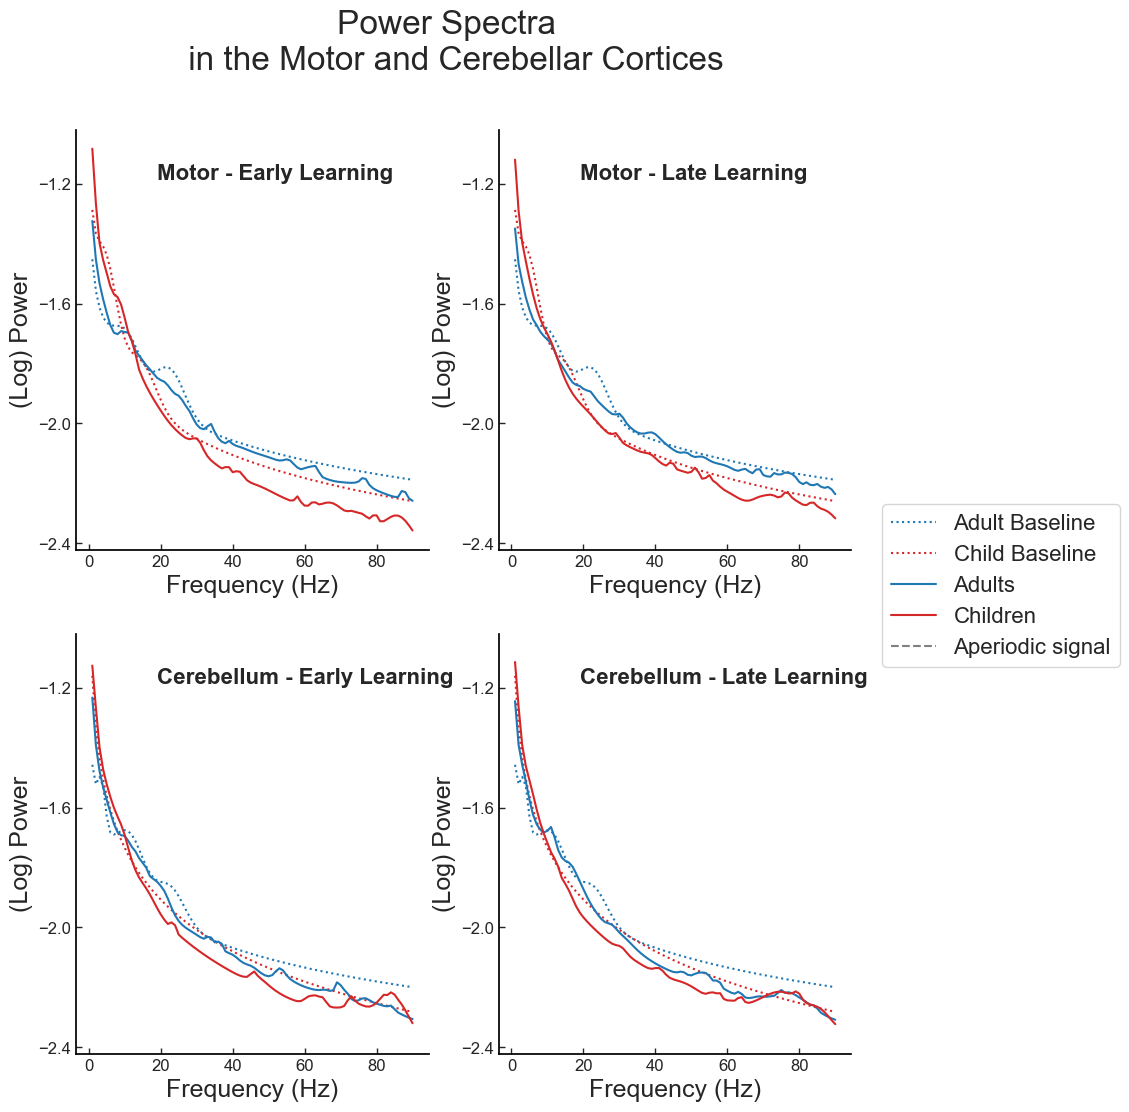

In [51]:
# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(10,12), sharex=True, sharey=True)
fig.suptitle("Power Spectra \n in the Motor and Cerebellar Cortices", fontsize=24)

# Loop through each condition + region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:
        # Dynamically load the right data
        adult_var_name = f"{condition}_{brain_region}_normalized_psds"
        child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
        adult_data = globals()[adult_var_name]
        child_data = globals()[child_var_name]

        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []

        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # === Adults
        for i in range(len(adult_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)

        # === Children
        for i in range(len(child_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)

        # === Averages
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # Add baseline power for comparison
        if brain_region == 'motor':
            adult_baseline = base_m_avg
            child_baseline = base_m_c_avg
        elif brain_region == 'cerebellum':
            adult_baseline = base_c_avg
            child_baseline = base_c_c_avg

        # === Subplot mapping
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]

        # FOOOF baseline power
        fm_base_adult = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                            min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
        fm_base_adult.fit(freqs, adult_baseline, freq_range)
        fooofed_adult_baseline = fm_base_adult.fooofed_spectrum_

        fm_base_child = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                            min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
        fm_base_child.fit(freqs, child_baseline, freq_range)
        fooofed_child_baseline = fm_base_child.fooofed_spectrum_

        # Plot FOOOF-modeled baseline spectra
        ax.plot(freqs, fooofed_adult_baseline, color='tab:blue', linestyle=':', label='Adult Baseline')
        ax.plot(freqs, fooofed_child_baseline, color='tab:red', linestyle=':', label='Child Baseline')

        # === Plot
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')
        # ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.6)
        # ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.6)

        # ax.fill_between(freqs[theta_mask], avg_child_background[theta_mask], avg_child_spectrum[theta_mask],
        #                 color='tab:red', alpha=0.3)
        # ax.fill_between(freqs[alpha_mask], avg_adult_background[alpha_mask], avg_adult_spectrum[alpha_mask],
        #                 color='tab:blue', alpha=0.3)
        # ax.axvspan(4, 8, color='red', alpha=0.08)
        # ax.axvspan(8, 12, color='blue', alpha=0.08)
        
        #Set Subplot Titles
        ax.text(0.23, 0.92,
        f"{brain_region.capitalize()} - {'Early' if condition == 'g_el' else 'Late'} Learning",
        transform=ax.transAxes,
        fontsize=16,
        weight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        ax.set_xlabel('Frequency (Hz)', fontsize=18)
        ax.set_ylabel('(Log) Power', fontsize=18)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)  # or 14 if you want bigger
        #ax.tick_params(top=True, right=True, direction='in', length=4, width=1)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')

# Custom aperiodic signal handle
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
handles.append(aperiodic_handle)
labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


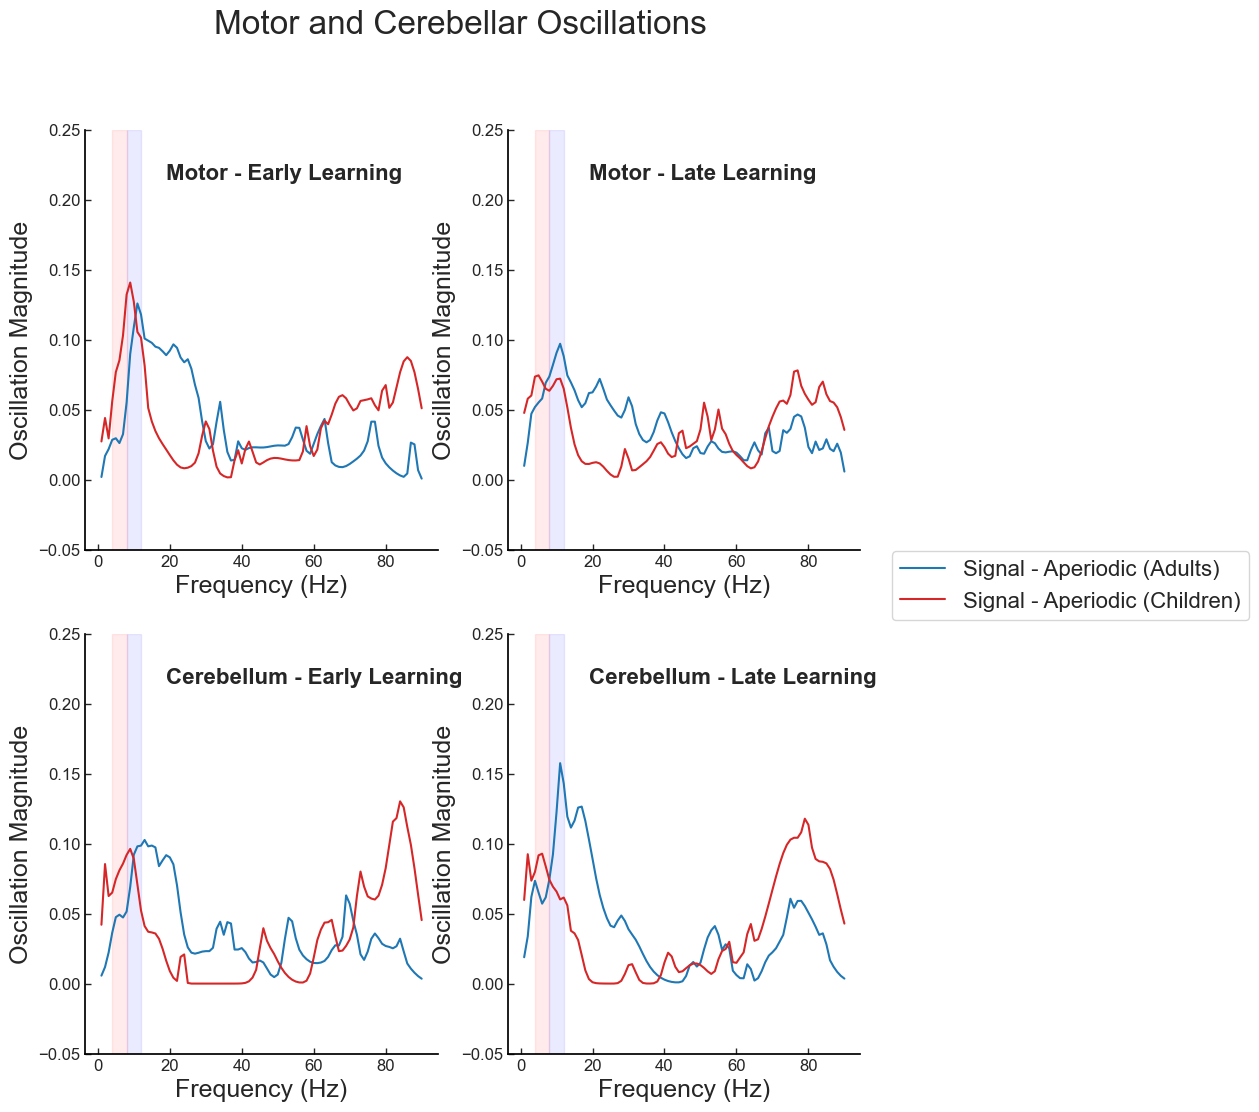

In [69]:
# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(10,12), sharex=True, sharey=True)
fig.suptitle("Motor and Cerebellar Oscillations", fontsize=24)

# Loop through each condition + region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:
        # Dynamically load the right data
        adult_var_name = f"{condition}_{brain_region}_normalized_psds"
        child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
        adult_data = globals()[adult_var_name]
        child_data = globals()[child_var_name]

        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []

        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # === Adults
        for i in range(len(adult_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)

        # === Children
        for i in range(len(child_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)

        # === Averages
        avg_adult_spectrum = np.mean(np.array(adult_spectra) - np.array(adult_backgrounds), axis=0)
        avg_child_spectrum = np.mean(np.array(child_spectra) - np.array(child_backgrounds), axis=0)

        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # === Subplot mapping
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]

        # # === Get baseline power for the current region
        # if brain_region == 'motor':
        #     adult_baseline = base_m_avg
        #     child_baseline = base_m_c_avg
        # elif brain_region == 'cerebellum':
        #     adult_baseline = base_c_avg
        #     child_baseline = base_c_c_avg

        # # Convert baseline PSD to log scale for comparison
        # log_adult_baseline = np.log10(adult_baseline)
        # log_child_baseline = np.log10(child_baseline)

        # # Difference between aperiodic component of task and baseline PSD
        # aperiodic_minus_baseline_adult = log_adult_baseline - avg_adult_background
        # aperiodic_minus_baseline_child = log_child_baseline - avg_child_background

        # # Plot difference
        # ax.plot(freqs, aperiodic_minus_baseline_adult, color='tab:blue', linestyle='-.', label='Resting - Aperiodic (Adult)')
        # ax.plot(freqs, aperiodic_minus_baseline_child, color='tab:red', linestyle='-.', label='Resting - Aperiodic (Child)')

        # === Plot
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Signal - Aperiodic (Adults)')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Signal - Aperiodic (Children)')
        ax.axvspan(4, 8, color='red', alpha=0.08)
        ax.axvspan(8, 12, color='blue', alpha=0.08)
        
        #Set Subplot Titles
        ax.text(0.23, 0.92,
        f"{brain_region.capitalize()} - {'Early' if condition == 'g_el' else 'Late'} Learning",
        transform=ax.transAxes,
        fontsize=16,
        weight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        ax.set_xlabel('Frequency (Hz)', fontsize=18)
        ax.set_ylabel('Oscillation Magnitude', fontsize=18)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)  # or 14 if you want bigger
        #ax.tick_params(top=True, right=True, direction='in', length=4, width=1)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        #ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        #ax.set_xticks([0, 20, 40, 60, 80])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')
        #ax.set_xlim(0,20)
        ax.set_ylim(-0.05,0.25)

# Custom aperiodic signal handle
#aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
# handles.append(aperiodic_handle)
# labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
print(len(el_m_std))
print(len(el_m_c_std))
print(len(el_c_std))
print(len(el_c_c_std))


90
90
90
90
0.0006051068770560168


TypeError: object of type 'numpy.float64' has no len()

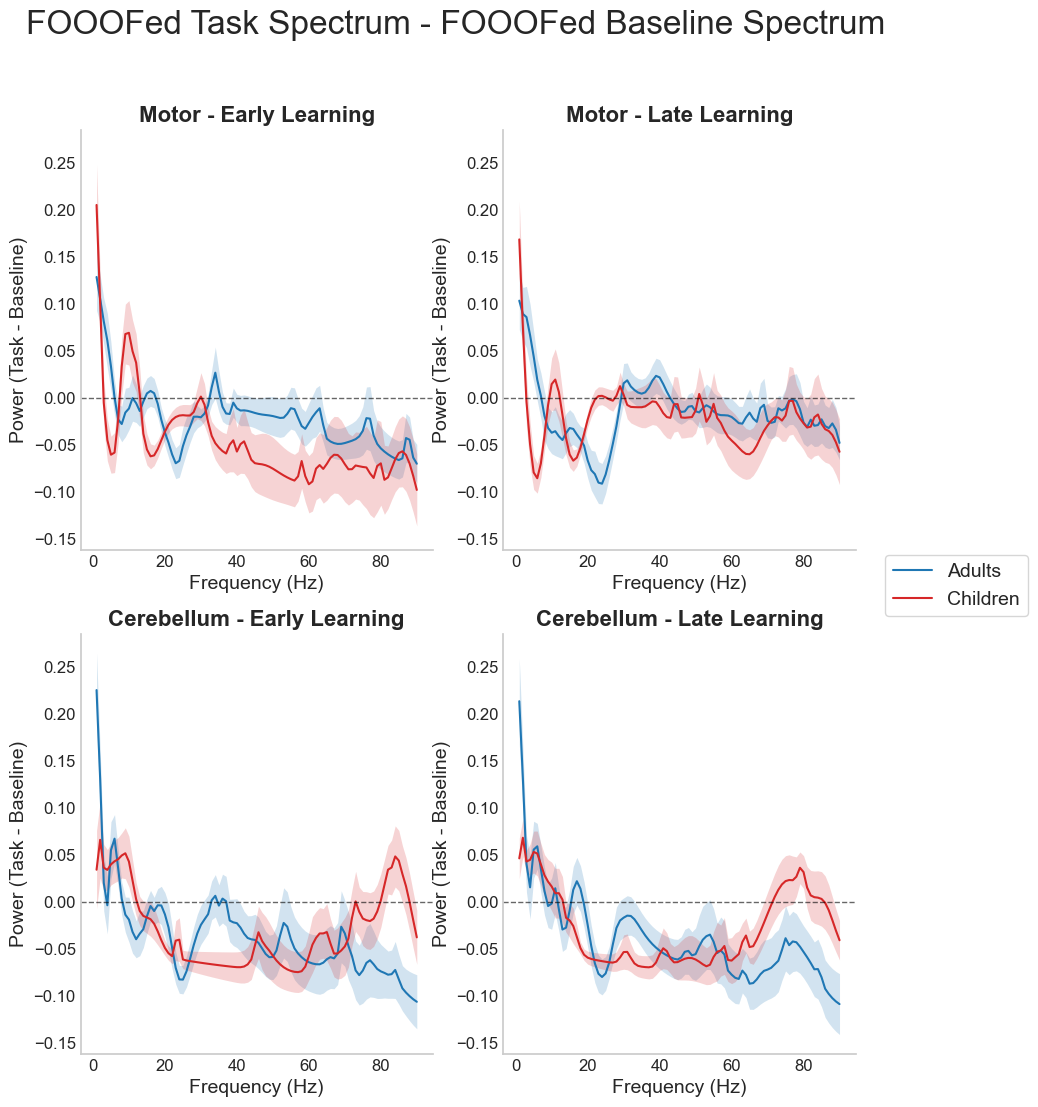

In [ ]:
# === NEW FIGURE: FOOOFed Signal minus FOOOFed Baseline ===
fig2, axs2 = plt.subplots(2, 2, figsize=(10, 12), sharex=True, sharey=True)
fig2.suptitle("FOOOFed Task Spectrum - FOOOFed Baseline Spectrum", fontsize=24)

# Loop again for each condition and brain region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:

        adult_var_name = f"{condition}_{brain_region}_normalized_psds"
        child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
        adult_data = globals()[adult_var_name]
        child_data = globals()[child_var_name]

        task_adult_fooofed, task_child_fooofed = [], []
        baseline_adult_fooofed, baseline_child_fooofed = [], []

        # === FOOOF the task spectra
        for i in range(len(adult_subs)):
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            task_adult_fooofed.append(fm.fooofed_spectrum_)

        for i in range(len(child_subs)):
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            task_child_fooofed.append(fm.fooofed_spectrum_)

        # === FOOOF the baseline spectra (already averaged before plotting)
        if brain_region == 'motor':
            adult_baseline = base_m_avg
            child_baseline = base_m_c_avg
        elif brain_region == 'cerebellum':
            adult_baseline = base_c_avg
            child_baseline = base_c_c_avg

        if brain_region == 'motor':
            if condition == 'g_el':
                std_adult = el_m_std
                std_child = el_m_c_std
            elif condition == 'g_ll':
                std_adult = ll_m_std
                std_child = ll_m_c_std
        elif brain_region == 'cerebellum':
            if condition == 'g_el':
                std_adult = el_c_std
                std_child = el_c_c_std
            elif condition == 'g_ll':
                std_adult = ll_c_std
                std_child = ll_c_c_std

        fm_base_adult = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                              min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
        fm_base_adult.fit(freqs, adult_baseline, freq_range)
        baseline_adult_fooofed = fm_base_adult.fooofed_spectrum_

        fm_base_child = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                              min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
        fm_base_child.fit(freqs, child_baseline, freq_range)
        baseline_child_fooofed = fm_base_child.fooofed_spectrum_

        # === Compute group-average differences
        task_adult_fooofed = np.array(task_adult_fooofed)
        task_child_fooofed = np.array(task_child_fooofed)

        diff_adult = np.mean(task_adult_fooofed, axis=0) - baseline_adult_fooofed
        diff_child = np.mean(task_child_fooofed, axis=0) - baseline_child_fooofed

        std_adult = np.std(task_adult_fooofed, axis=0) / np.sqrt(task_adult_fooofed.shape[0])
        std_child = np.std(task_child_fooofed, axis=0) / np.sqrt(task_child_fooofed.shape[0])


        # === Plotting
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs2[row][col]

        # Only label once to avoid legend duplicates
        label_adult = 'Adults' if (condition == 'g_el' and brain_region == 'motor') else None
        label_child = 'Children' if (condition == 'g_el' and brain_region == 'motor') else None

        ax.plot(freqs, diff_adult, color='tab:blue', label=label_adult)
        ax.plot(freqs, diff_child, color='tab:red', label=label_child)
        # Adults
        ax.fill_between(freqs, diff_adult - std_adult, diff_adult + std_adult,
                        color='tab:blue', alpha=0.2, linewidth=0)

        # Children
        ax.fill_between(freqs, diff_child - std_child, diff_child + std_child,
                        color='tab:red', alpha=0.2, linewidth=0)

        ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
        # ax.axvspan(4, 8, color='red', alpha=0.08)
        # ax.axvspan(8, 12, color='blue', alpha=0.08)

        ax.set_title(f"{brain_region.capitalize()} - {'Early' if condition == 'g_el' else 'Late'} Learning", fontsize=16, weight='bold')
        ax.set_xlabel('Frequency (Hz)', fontsize=14)
        ax.set_ylabel('Power (Task - Baseline)', fontsize=14)
        ax.tick_params(axis='both', which='both', direction='in', length=4, width=1, labelsize=12)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.yaxis.set_tick_params(labelleft=True)

        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig2.legend(loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=14)
plt.show()


In [53]:
#Save Data 
np.save(op.join('psd_data', 'el_cerebellum_normalized_psds'), el_cerebellum_normalized_psds)
np.save(op.join('psd_data','ll_cerebellum_normalized_psds'), ll_cerebellum_normalized_psds)
np.save(op.join('psd_data','rl_cerebellum_normalized_psds'), rl_cerebellum_normalized_psds)
np.save(op.join('psd_data','el_cerebellum_normalized_psds_c'), el_cerebellum_normalized_psds_c)
np.save(op.join('psd_data','ll_cerebellum_normalized_psds_c'), ll_cerebellum_normalized_psds_c)
np.save(op.join('psd_data','rl_cerebellum_normalized_psds_c'), rl_cerebellum_normalized_psds_c)

#Save Stds, sig_freqs as well 
np.save(op.join('psd_data','std_el_c'), el_c_std)
np.save(op.join('psd_data','std_ll_c'), ll_c_std)
np.save(op.join('psd_data','std_rl_c'), rl_c_std)
np.save(op.join('psd_data','std_el_c_c'), el_c_std)
np.save(op.join('psd_data','std_ll_c_c'), ll_c_std)
np.save(op.join('psd_data','std_rl_c_c'), rl_c_std)

np.save(op.join('psd_data', 'sig_freqs_cereb_age'), sig_freqs_cereb_age)
np.save(op.join('psd_data', 'sig_freqs_cereb_cond'), sig_freqs_cereb_cond)
np.save(op.join('psd_data', 'sig_freqs_cereb_int'), sig_freqs_cereb_int)

np.save(op.join('psd_data', 'el_motor_normalized_psds'), el_motor_normalized_psds)
np.save(op.join('psd_data', 'll_motor_normalized_psds'), ll_motor_normalized_psds)
np.save(op.join('psd_data', 'rl_motor_normalized_psds'), rl_motor_normalized_psds)
np.save(op.join('psd_data', 'el_motor_normalized_psds_c'), el_motor_normalized_psds_c)
np.save(op.join('psd_data', 'll_omtor_normalized_psds_c'), ll_motor_normalized_psds_c)
np.save(op.join('psd_data', 'rl_motor_normalized_psds_c'), rl_motor_normalized_psds_c)

np.save(op.join('psd_data', 'el_m_std'), el_m_std)
np.save(op.join('psd_data', 'll_m_std'), ll_m_std)
np.save(op.join('psd_data', 'rl_m_std'), rl_m_std)
np.save(op.join('psd_data', 'el_m_std_c'), el_m_c_std)
np.save(op.join('psd_data', 'll_m_std_c'), ll_m_c_std)
np.save(op.join('psd_data', 'rl_m_std_c'), rl_m_c_std)

np.save(op.join('psd_data', 'sig_freqs_m_age'), sig_freqs_m_age)
np.save(op.join('psd_data', 'sig_freqs_m_cond'), sig_freqs_m_cond)
np.save(op.join('psd_data', 'sig_freqs_m_int'), sig_freqs_m_int)

Showing: t = 0.339 s, (5.0, -65.0, -20.0) mm, [17, 10, 11] vox, 14867 vertex
Using control points [0.03692496 0.04147356 0.07665115]


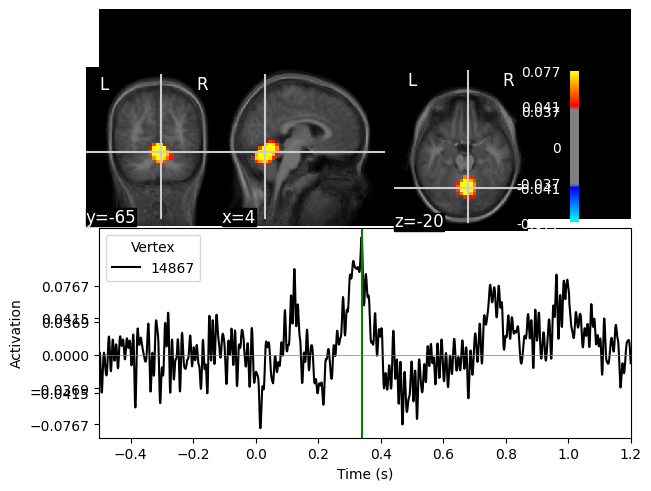

Showing: t = 0.265 s, (0.0, -60.0, -15.0) mm, [16, 11, 12] vox, 15823 vertex
Using control points [0.01490403 0.01700169 0.03794668]


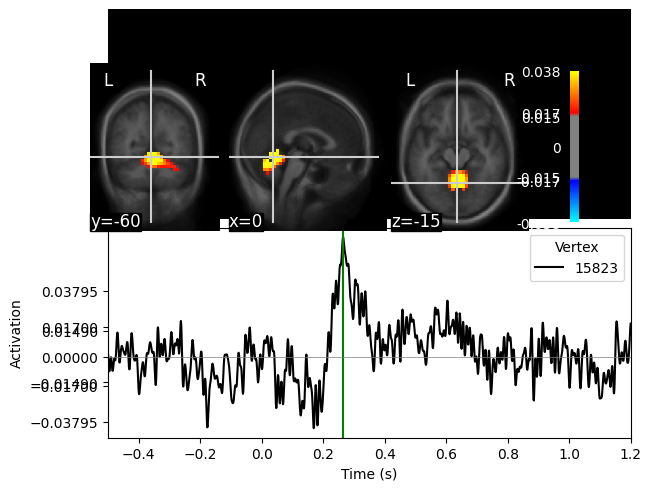

Using control points [0.03842845 0.04298155 0.07904477]


In [83]:
child_stc = mne.read_source_estimate(op.join(path, 'MEG', 'VML_child_morphed-averaged_DS_run 3 -stc.h5'))
adult_stc = mne.read_source_estimate(op.join(path, 'MEG', 'VML_adult_morphed-averaged_DS_run 3 -stc.h5'))
child_src = mne.read_source_spaces(op.join(path, 'MRI', 'vml_avg_child', 'bem', 'vml_avg_child-mixed-src.fif'), verbose=False)
adult_src = mne.read_source_spaces(op.join(path, 'MRI', 'fsaverage', 'bem', 'fsaverage-mixed-src.fif'), verbose=False)

child_surf_stc = child_stc.surface()
child_vol_stc = child_stc.volume()

adult_surf_stc = adult_stc.surface()
adult_vol_stc = adult_stc.volume()

brain = child_vol_stc.plot(
    src=child_src,
    subject='vml_avg_child',
    subjects_dir=mri_path
)

# child_vol_stc.save_as_volume(op.join(meg_path, 'volume_stcs', 'child_EL'), src=child_src, dest='mri', mri_resolution=False, format='nifti1', overwrite=True, verbose=None)
# adult_vol_stc.save_as_volume(op.join(meg_path, 'volume_stcs', 'adult_EL'), src=adult_src, dest='mri', mri_resolution=False, format='nifti1', overwrite=True, verbose=None)

# child_surf_stc.save_as_surface(op.join(meg_path, 'volume_stcs', 'surf_child_EL'), src=child_src, scale=1)
# adult_surf_stc.save_as_surface(op.join(meg_path, 'volume_stcs', 'surf_adult_EL'), src=adult_src, scale=1)

brain1 = adult_vol_stc.plot(
    src=adult_src,
    subject='fsaverage',
    subjects_dir=mri_path
)

brain3 = child_stc.plot(src=child_src,
    subject='vml_avg_child',
    subjects_dir=mri_path, 
    surface='pial',
    hemi='both')

[<nibabel.nifti1.Nifti1Image object at 0x000001EF828519A0>, <nibabel.nifti1.Nifti1Image object at 0x000001EF88623230>]
File 0: /users/mgarson.stu/.anaconda/VML\MEG\volume_stcs\adult_EL.nii | Shape: (33, 39, 34, 1701)
File 1: /users/mgarson.stu/.anaconda/VML\MEG\volume_stcs\adult_LL.nii | Shape: (33, 39, 34, 1701)


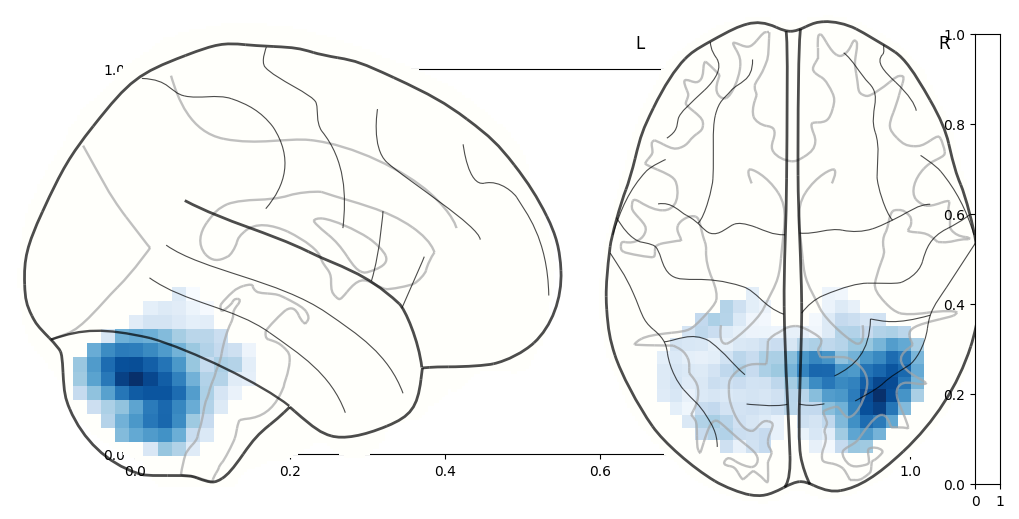

In [71]:
#Plotting using Nilearn 
import nilearn.plotting as plotting
import nilearn.image as image
import matplotlib.pyplot as plt

# List of .nii files
nii_files = [
    (op.join(meg_path, 'volume_stcs',  'adult_EL.nii')),
    (op.join(meg_path, 'volume_stcs',  'adult_LL.nii'))
]

# Load the standard brain template
template = image.load_img(op.join(mri_path, 'fsaverage', 'mri', 'FSL_MNI152_FreeSurferConformed_1mm.nii.gz'))

# Choose a time index manually (modify this as needed)
time_idx = 10  # Example: select the 10th time point

#Keep 4D
nii_imgs_4d = [image.load_img(nii) for nii in nii_files]
print((nii_imgs_4d))

# Print shape information
for i, img in enumerate(nii_imgs_4d):
    print(f"File {i}: {nii_files[i]} | Shape: {img.shape}")


# Load the nii images and extract a specific time point (convert 4D → 3D)
nii_imgs = [image.index_img(image.load_img(nii), time_idx) for nii in nii_files]

cmap = "magma"  # Better perceptual colormap
vmin = 0
vmax = np.percentile(nii_imgs[0].get_fdata(), 95)  # Avoids extreme intensity dominance

# Create an overlay plot
fig, ax = plt.subplots(figsize=(10, 5))
display = plotting.plot_glass_brain(template, figure=fig, display_mode="xz", black_bg=False, threshold='auto', vmin=vmin, vmax=vmax, colorbar=True)

# Overlay each nii file with different colormaps and transparencies
cmaps = ["Reds", "Blues", "Purples"]  # Adjust as needed
alphas = [1,1,1]  # Transparency levels

for nii_img, cmap, alpha in zip(nii_imgs, cmaps, alphas):
    display.add_overlay(nii_img, cmap=cmap, alpha=alpha)

plt.show()